# Avance 2. Ingeniería de características (Feature Engineering)
**Proyecto Berry-Vision — Clasificación de arándanos defectuosos mediante visión computacional e inteligencia artificial**

**Equipo #6** · Proyecto Integrador MNA · Metodología CRISP-ML(Q), fase *Data Preparation*

| Integrante | Matrícula |
|---|---|
| José Luis Parada Gutiérrez | A00939669 |
| Kevin Rosario Cota Rodríguez | A01796705 |
| Rolando David Villarreal Martínez | A00609894 |

---
**Objetivos del avance**
- 2.3 Crear nuevas características para mejorar el rendimiento de los modelos.
- 2.4 Mitigar el riesgo de características sesgadas y acelerar la convergencia de algunos algoritmos.

Este avance transforma los recortes de arándano en una tabla de características lista para modelar. Persigue dos objetivos: crear variables nuevas que mejoren el rendimiento de los modelos (2.3) y corregir el sesgo de las distribuciones para acelerar la convergencia (2.4).

Parte de lo que mostró el EDA: Las imágenes son frutos individuales (bueno/malo), la clase de interés es malo, varias variables son muy asimétricas y el color y la textura son lo más discriminativo. Además existe el riesgo de que el modelo aprenda la sesión de captura (la iluminación) en lugar del defecto.

La regla que gobierna todo el cuaderno es evitar la fuga de datos. Todo lo que aprende de los datos (transformaciones, escaladores, bins, filtros, PCA/FA) se ajusta únicamente con entrenamiento y luego se aplica a validación y prueba. Las alternativas se comparan con validación cruzada agrupada por bloques de imágenes consecutivas, porque los recortes capturados seguidos comparten iluminación. Los filtros se ajustan dentro de cada pliegue. El conjunto de prueba no interviene en ninguna decisión.

El notebook avanza de la preparación de datos y características base (secciones 1-2) a su construcción, codificación, transformación y escalamiento (3-6). Cierra con la selección, extracción y exportación (7-8) y las conclusiones (9).


**Contenido**
1. Configuración, datos, control de calidad y partición
2. Características base extraídas de cada recorte
3. Generación de nuevas características (construcción, discretización)
4. Codificación de variables categóricas
5. Transformación (corrección de asimetría)
6. Escalamiento y convergencia
7. Selección (filtros) y extracción (PCA, FA y píxeles) de características
8. Conjunto final y exportación
9. Conclusiones de la fase *Preparación de los datos* (CRISP-ML(Q))

## 1. Configuración, datos, control de calidad y partición

In [1]:
import os, sys, re, time, json, warnings
from pathlib import Path
import numpy as np, pandas as pd, cv2, joblib
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from IPython.display import display, Markdown
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import f_classif, mutual_info_classif, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, recall_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (MinMaxScaler, StandardScaler, RobustScaler, PowerTransformer,
                                   KBinsDiscretizer, OneHotEncoder, OrdinalEncoder)
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60, "display.width", 180)
SEED = 42
rng = np.random.default_rng(SEED)

# ---- Rutas: Colab (Drive) o ejecución local ----------------------------------------------
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    _root = Path("/content/drive/MyDrive/ProyectoIntegrador")
    _ds, _out = _root / "Semana4/v2", _root / "Datos/resultados_avance2"
else:
    _ds = next((p for p in [Path("../Datos/Semana4/v2"), Path("Datos/Semana4/v2")] if p.exists()), Path("../Datos/Semana4/v2"))
    _out = Path("../Datos/resultados_avance2") if Path("../Datos").exists() else Path("resultados_avance2")
DS_DIR = Path(os.environ.get("BERRY_DATA_DIR", _ds))          # carpeta v2 con output/ (recortes) y etiquetas.csv
OUT_DIR = Path(os.environ.get("BERRY_OUT_DIR", _out))         # solo tablas agregadas (sin imágenes)
OUT_DIR.mkdir(parents=True, exist_ok=True)
CROP_PADDING, CROP_SIZE = 20, 200                              # mismo criterio del Avance 1
print("Datos:", DS_DIR.resolve(), "| Salidas:", OUT_DIR.resolve(), "| Colab:", IN_COLAB)

Mounted at /content/drive
Datos: /content/drive/.shortcut-targets-by-id/1D3LM7dIWfg66NB2euECFRQF0hvwhPH31/ProyectoIntegrador/Semana4/v2 | Salidas: /content/drive/.shortcut-targets-by-id/1D3LM7dIWfg66NB2euECFRQF0hvwhPH31/ProyectoIntegrador/Datos/resultados_avance2 | Colab: True


### 1.1 Etiquetas (versión 2 (v2) de la base de datos)
El archivo etiquetas.csv de la v2 trae, por cada recorte, su posición en el fruto (cx, cy, radio) y su clase (good/bad). Se traduce a bueno/malo para mantener la nomenclatura del proyecto y se descartan los registros sin etiqueta, ya que imputar una clase metería ruido en un criterio definido por el negocio.

Esta versión tiene dos diferencias que condicionan el diseño. Ya no incluye las fotos originales, así que el número del archivo (blueberry (N).png), que sigue el orden de captura, sirve para formar los grupos de validación (se verifica en 1.4). Tampoco trae el tipo de defecto, por lo que la sección 4 solo lo codificaría si la columna existiera.

In [2]:
lab_path = next((p for p in [DS_DIR / "etiquetas.csv", Path("../Datos/Semana4/v2/etiquetas.csv")] if p.exists()), None)
assert lab_path is not None, f"No se encontró etiquetas.csv en {DS_DIR}"
try:
    et = pd.read_csv(lab_path, encoding="utf-8-sig")
except UnicodeDecodeError:
    et = pd.read_csv(lab_path, encoding="cp1252")
et["clase"] = (et["clase"].astype("string").str.strip().str.lower()
               .replace({"good": "bueno", "bad": "malo", "buena": "bueno", "mala": "malo"}))
print(f"{len(et)} recortes en {lab_path.name} · {et.nombre.nunique()} imágenes · {int(et.clase.isna().sum())} sin etiqueta (se descartan)")
et = et.dropna(subset=["clase"]).reset_index(drop=True)
et["clase"] = et["clase"].astype(object)
assert et.id.is_unique and et.nombre.is_unique
HAY_DEFECTO = "defecto" in et.columns
if HAY_DEFECTO:
    et["defecto"] = et["defecto"].astype("string").str.strip().str.lower().astype(object)

et["crop_id"] = et.nombre.str.replace(".png", "", regex=False)
et["n_img"] = et.nombre.str.extract(r"[(]([0-9]+)[)]")[0].astype(int)       # número de captura
BLOQUE = 5                                                                   # una foto de la banda tiene como máximo 5 frutos
et["grupo"] = "b" + ((et.n_img - 1) // BLOQUE).astype(str)
display(et.clase.value_counts().to_frame("recortes").assign(**{"%": lambda d: (d.recortes / d.recortes.sum() * 100).round(1)}))
print(f"¿La v2 trae tipo de defecto? {HAY_DEFECTO} · {et.grupo.nunique()} grupos de validación (bloques de {BLOQUE} números consecutivos)")

353 recortes en etiquetas.csv · 353 imágenes · 0 sin etiqueta (se descartan)


,recortes,%
clase,,
bueno,222,62.9
malo,131,37.1


¿La v2 trae tipo de defecto? False · 84 grupos de validación (bloques de 5 números consecutivos)


### 1.2 Recortes de 200×200 y características base
Cada recorte se ajusta al criterio del Avance 1 (cuadrado de lado 2·(radio+20)) y se reduce a 200×200 con INTER_AREA. Sobre él se miden cinco familias de características, elegidas por lo que cada una revela del estado del fruto:

| Grupo | Características | Qué captura (conocimiento del dominio) |
|---|---|---|
| Tamaño/forma | `radio`, `area_fruto_pct`, `circularidad`, `solidez`, `relacion_ejes` | Calibre; golpes y hundimientos deforman el contorno |
| Color (RGB/HSV/Lab) | `R/G/B_fruto`, `matiz`, `saturacion`, `valor`, `L/a/b` | Azul-marino sano vs. rojizo/café/pálido (descomposición, flor seca, deshidratación) |
| Manchas de color | `pct_rojizo`, `pct_marron`, `pct_palido`, `pct_oscuro`, `pct_brillo`, `mancha_max` | Superficie con color anómalo (cicatriz, flor seca, moho) |
| Brillo/nitidez | `brillo_fruto`, `contraste_fruto`, `nitidez`, `fondo_brillo` | Iluminación y enfoque de la captura |
| Textura | `glcm_*` (contraste, homogeneidad, energía, correlación), `lbp_entropia`, `densidad_bordes`, `brillo_centro_periferia` | Piel lisa y cerosa vs. arrugada (deshidratado) o hundida (golpe) |

El fruto se segmenta por Otsu y las estadísticas se miden solo en su zona interior (más del 15 % del radio inscrito), porque en el borde se mezcla con el fondo y aparecen halos rojizos o pálidos que no son defectos. También se guardan miniaturas de 32×32 (para el PCA de píxeles) y los recortes de 200×200 (para normalizar la CNN).

In [3]:
def recortar(img, r):
    h, w = img.shape[:2]
    cx, cy, R = int(round(r.cx)), int(round(r.cy)), int(r.radio) + CROP_PADDING
    c = img[max(0, cy - R):min(h, cy + R), max(0, cx - R):min(w, cx + R)]
    return cv2.resize(c, (CROP_SIZE, CROP_SIZE), interpolation=cv2.INTER_AREA)

def extraer(c):
    """Características de un recorte BGR de 200x200. Devuelve (base, locales); dicts parciales si no hay fruto."""
    gray = cv2.cvtColor(c, cv2.COLOR_BGR2GRAY); hsv = cv2.cvtColor(c, cv2.COLOR_BGR2HSV); lab = cv2.cvtColor(c, cv2.COLOR_BGR2LAB)
    ring = np.concatenate([gray[:6].ravel(), gray[-6:].ravel(), gray[:, :6].ravel(), gray[:, -6:].ravel()])
    r, loc = {"fondo_brillo": float(np.median(ring))}, {}
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, m = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    cn = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]
    if not cn:
        return r, loc
    k = max(cn, key=cv2.contourArea); A, P = cv2.contourArea(k), cv2.arcLength(k, True)
    fm = np.zeros_like(gray); cv2.drawContours(fm, [k], -1, 255, -1)
    hull = cv2.contourArea(cv2.convexHull(k))
    (_, _), (a1, a2), _ = cv2.fitEllipse(k) if len(k) >= 5 else ((0, 0), (1, 1), 0)
    r.update(area_fruto_pct=A / gray.size, circularidad=4 * np.pi * A / P ** 2, solidez=A / hull,
             relacion_ejes=min(a1, a2) / max(a1, a2, 1e-9))
    # Zona interior (> 15 % del radio inscrito): evita el borde, donde el fruto se mezcla con el fondo y aparecen halos rojizos/pálidos falsos
    d = cv2.distanceTransform(fm, cv2.DIST_L2, 5); rr = d.max(); s = d > .15 * rr
    B, G, R = [c[..., i][s].astype(float) for i in range(3)]
    Hh = hsv[..., 0][s].astype(float) * 2; S = hsv[..., 1][s].astype(float); V = hsv[..., 2][s].astype(float)
    L, a, b = lab[..., 0][s].astype(float), lab[..., 1][s].astype(float) - 128, lab[..., 2][s].astype(float) - 128
    rad = np.radians(Hh)
    r.update(R_fruto=R.mean(), G_fruto=G.mean(), B_fruto=B.mean(),
             matiz=float(np.degrees(np.arctan2(np.sin(rad).mean(), np.cos(rad).mean())) % 360),   # media circular
             saturacion=S.mean(), valor=V.mean(), L_medio=L.mean(), a_medio=a.mean(), b_medio=b.mean(),
             brillo_fruto=gray[s].mean(), contraste_fruto=gray[s].std(), nitidez=cv2.Laplacian(gray, cv2.CV_64F)[s].var())
    rojizo = ((Hh >= 300) | (Hh <= 30)) & (S > 50) & (V > 40)
    marron = (Hh > 10) & (Hh <= 50) & (S > 50) & (V > 50)
    palido = (S < 45) & (V > 110)
    r.update(pct_rojizo=rojizo.mean(), pct_marron=marron.mean(), pct_palido=palido.mean(),
             pct_oscuro=(V < 50).mean(), pct_brillo=(gray[s] >= 235).mean())
    anom = np.zeros(gray.shape, np.uint8); anom[s] = (rojizo | marron | palido).astype(np.uint8)
    n, _, st, _ = cv2.connectedComponentsWithStats(anom)
    r["mancha_max"] = (st[1:, cv2.CC_STAT_AREA].max() / s.sum()) if n > 1 else 0.0
    q = (gray // 8).astype(np.uint8); x, y, w, h = cv2.boundingRect(k)
    gm = graycomatrix(q[y:y + h, x:x + w], [2], [0, np.pi / 2], levels=32, symmetric=True, normed=True)
    for nom, p in [("contraste", "contrast"), ("homogeneidad", "homogeneity"), ("energia", "energy"), ("correlacion", "correlation")]:
        r["glcm_" + nom] = float(graycoprops(gm, p).mean())
    lbp = local_binary_pattern(gray, 8, 1, "uniform")[s].astype(int)
    hh = np.bincount(lbp, minlength=10) / s.sum()
    r["lbp_entropia"] = float(-(hh[hh > 0] * np.log2(hh[hh > 0])).sum())
    r["densidad_bordes"] = float((cv2.Canny(blur, 30, 90)[cv2.erode(fm, np.ones((9, 9), np.uint8)) > 0] > 0).mean())
    r["brillo_centro_periferia"] = gray[d > .6 * rr].mean() / max(gray[(d > .15 * rr) & (d < .4 * rr)].mean(), 1)
    # --- Descriptores locales (distribución dentro del fruto): colas, gradiente y micro-textura ---
    rojez = R - B
    gx, gy = cv2.Sobel(gray, cv2.CV_32F, 1, 0), cv2.Sobel(gray, cv2.CV_32F, 0, 1); grad = np.hypot(gx, gy)[s]
    loc.update(rojez_p95=np.percentile(rojez, 95), rojez_p99=np.percentile(rojez, 99), rojez_std=rojez.std(),
               L_p5=np.percentile(L, 5), L_p95=np.percentile(L, 95), L_std=L.std(),
               a_p95=np.percentile(a, 95), b_p95=np.percentile(b, 95), sat_p95=np.percentile(S, 95), sat_std=S.std(),
               grad_med=grad.mean(), grad_p95=np.percentile(grad, 95))
    loc.update({f"lbp_p{i}": hh[i] for i in range(10)})
    return r, loc

t0 = time.perf_counter()
filas, C200, T32 = [], [], []
for r in et.itertuples():
    p = DS_DIR / "output" / r.nombre
    img = cv2.imdecode(np.fromfile(str(p), np.uint8), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"No se pudo leer {p}. Revise DS_DIR/output.")
    c = recortar(img, r)
    d, dl = extraer(c); d["crop_id"] = r.crop_id; d.update(dl)
    filas.append(d); C200.append(c); T32.append(cv2.resize(c, (32, 32), interpolation=cv2.INTER_AREA))
C200, T32 = np.stack(C200), np.stack(T32)
raw = pd.DataFrame(filas).merge(et, on="crop_id", how="left")        # conserva el orden de C200/T32
assert len(raw) == len(C200) == len(et)
print(f"Extracción: {len(raw)} recortes en {time.perf_counter() - t0:.0f} s")

BASE = ["radio", "area_fruto_pct", "circularidad", "solidez", "relacion_ejes",
        "R_fruto", "G_fruto", "B_fruto", "matiz", "saturacion", "valor", "L_medio", "a_medio", "b_medio",
        "brillo_fruto", "contraste_fruto", "nitidez", "fondo_brillo",
        "pct_rojizo", "pct_marron", "pct_palido", "pct_oscuro", "pct_brillo", "mancha_max",
        "glcm_contraste", "glcm_homogeneidad", "glcm_energia", "glcm_correlacion", "lbp_entropia",
        "densidad_bordes", "brillo_centro_periferia"]
LOCAL = ["rojez_p95", "rojez_p99", "rojez_std", "L_p5", "L_p95", "L_std", "a_p95", "b_p95", "sat_p95", "sat_std", "grad_med", "grad_p95"] + [f"lbp_p{i}" for i in range(10)]
print(f"{len(BASE)} características base · {len(LOCAL)} descriptores locales (sección 3.2)")
raw[["crop_id", "clase"] + BASE[:6]].head()

Extracción: 353 recortes en 313 s
31 características base · 22 descriptores locales (sección 3.2)


,crop_id,clase,radio,area_fruto_pct,circularidad,solidez,relacion_ejes,R_fruto
0,blueberry (1),bueno,320.0,0.557575,0.847143,0.983291,0.802211,49.613420
1,blueberry (10),bueno,324.0,0.580438,0.700064,0.969092,0.864432,60.046320
2,blueberry (100),bueno,395.0,0.546125,0.580258,0.939954,0.823734,46.035236
3,blueberry (101),bueno,371.0,0.520038,0.464538,0.917659,0.801378,46.815667
4,blueberry (102),bueno,417.0,0.575838,0.454373,0.933683,0.841196,48.906478


### 1.3 Control de calidad
Se excluyen los recortes que son fallas de adquisición y no variación real del producto: los de radio atípicamente pequeño (menor que Q1 − 1.5·IQR), que son detecciones espurias de pocos píxeles, y los sin fruto segmentable (área menor al 30 % del recorte). En cambio se conservan los atípicos de color y forma, porque un arándano defectuoso es, por definición, atípico en esas variables.

In [4]:
q1, q3 = raw.radio.quantile([.25, .75]); lim_inf = q1 - 1.5 * (q3 - q1)
qc = pd.DataFrame({"radio_atipico": raw.radio < lim_inf,
                   "sin_fruto": raw.area_fruto_pct.isna() | (raw.area_fruto_pct < .30)})
print(f"Límite inferior del radio: {lim_inf:.0f} px")
display(qc.sum().to_frame("n").T)
keep = ~qc.any(axis=1)
display(raw[~keep][["crop_id", "radio", "clase"]])
datos = raw[keep].reset_index(drop=True)
C200, T32 = C200[keep.values], T32[keep.values]
assert datos[BASE].isna().sum().sum() == 0
print(f"Se conservan {len(datos)} de {len(raw)} recortes · clases: {datos.clase.value_counts().to_dict()}")

Límite inferior del radio: 170 px


,radio_atipico,sin_fruto
n,0,0


,crop_id,radio,clase


Se conservan 353 de 353 recortes · clases: {'bueno': 222, 'malo': 131}


### 1.4 Partición 70/15/15 estratificada y agrupada por bloques de captura
Los frutos fotografiados juntos comparten iluminación y fondo. Si se repartieran entre entrenamiento y prueba, el modelo podría reconocer la sesión y las métricas saldrían infladas. Como la v2 no indica la foto de origen, se usa el número de archivo como aproximación del orden de captura, y primero se comprueba que hay estructura: la autocorrelación del brillo del fondo entre recortes consecutivos debe ser positiva frente a un orden aleatorio.

In [5]:
orden = raw.sort_values("n_img")
x = orden.fondo_brillo.values
xa = np.random.default_rng(SEED).permutation(x)
ac = lambda v, k: float(np.corrcoef(v[:-k], v[k:])[0, 1])
display(pd.DataFrame({"autocorrelación": [ac(x, 1), ac(x, 2), ac(x, 5), ac(x, 20), ac(xa, 1)]},
                     index=["lag 1", "lag 2", "lag 5", "lag 20", "orden aleatorio (lag 1)"]).round(3))
print("Los recortes cercanos en numeración tienen iluminación parecida (autocorrelación > 0 a lag corto, ≈ 0 al barajar): "
      "separar vecinos entre train y test sería fuga. Se agrupan en bloques de 5 números consecutivos.")

,autocorrelación
lag 1,0.185
lag 2,0.333
lag 5,0.192
lag 20,-0.029
orden aleatorio (lag 1),-0.048


Los recortes cercanos en numeración tienen iluminación parecida (autocorrelación > 0 a lag corto, ≈ 0 al barajar): separar vecinos entre train y test sería fuga. Se agrupan en bloques de 5 números consecutivos.


Con esa evidencia se agrupan los recortes en bloques de 5 números consecutivos y se reparten con StratifiedGroupKFold (7 pliegues: 1 para prueba, 1 para validación y 5 para entrenamiento, ≈ 71/14/14 %), que mantiene la proporción de clases y cada bloque en una sola partición. Supuesto por confirmar con SOLID México: que la numeración respete el orden de captura. Si no fuera así, la agrupación es inocua pero no protege contra la fuga.

In [6]:
sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
y_all = (datos.clase == "malo").astype(int)           # clase positiva = "malo" (la de interés; falso negativo = fruto defectuoso aceptado)
datos["y"] = y_all
fold = np.empty(len(datos), int)
for i, (_, te) in enumerate(sgkf.split(datos, y_all, datos.grupo)):
    fold[te] = i
datos["particion"] = np.where(fold == 0, "test", np.where(fold == 1, "val", "train"))
assert datos.groupby("grupo").particion.nunique().max() == 1
tab = pd.crosstab(datos.particion, datos.clase, margins=True)
tab["% malo"] = (tab["malo"] / tab["All"] * 100).round(1)
display(tab.loc[["train", "val", "test", "All"]])

tr, va, te = [(datos.particion == s).values for s in ["train", "val", "test"]]
TRAIN, VAL, TEST = datos[tr].reset_index(drop=True), datos[va].reset_index(drop=True), datos[te].reset_index(drop=True)
print("Partición lista · el conjunto de prueba NO se usa en este avance para decidir nada.")

clase,bueno,malo,All,% malo
particion,,,,
train,163,95,258,36.8
val,29,16,45,35.6
test,30,20,50,40.0
All,222,131,353,37.1


Partición lista · el conjunto de prueba NO se usa en este avance para decidir nada.


## 2. Características base: panorama
Antes de construir variables nuevas se mide qué tan informativa es cada característica base con el AUC de Mann–Whitney (0.5 significa sin poder discriminativo; es el mismo criterio del EDA), calculado solo con entrenamiento. Sirve de referencia para juzgar después si lo construido aporta algo.

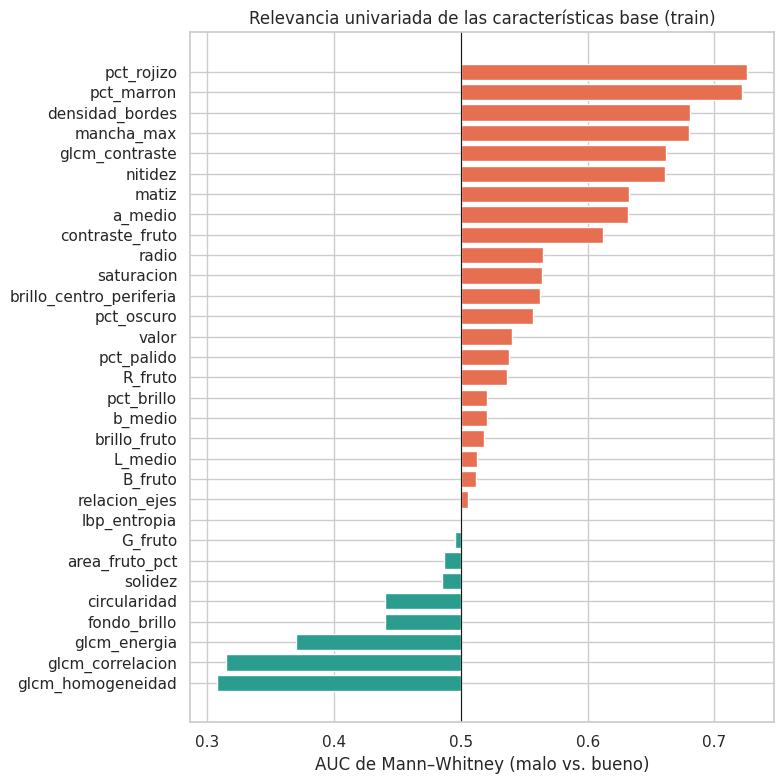

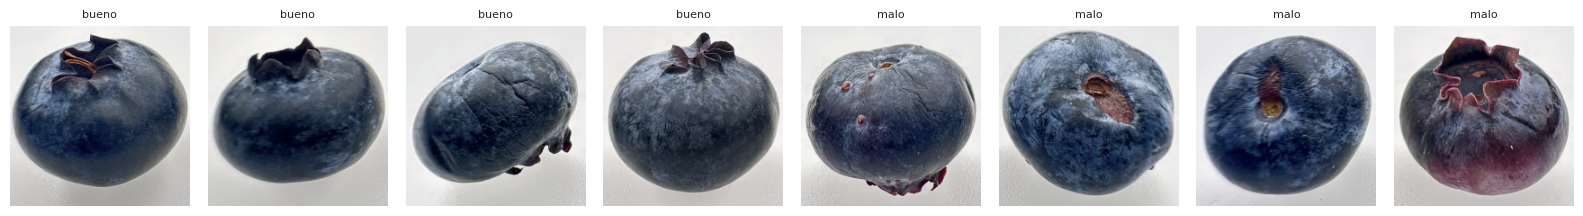

In [7]:
def auc_u(x, y):
    a, b = x[y == 1].dropna(), x[y == 0].dropna()
    return stats.mannwhitneyu(a, b).statistic / (len(a) * len(b))

rel_base = pd.Series({f: auc_u(TRAIN[f], TRAIN.y) for f in BASE}).sort_values()
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(rel_base.index, rel_base.values - .5, left=.5, color=np.where(rel_base.values >= .5, "#e76f51", "#2a9d8f"))
ax.axvline(.5, c="k", lw=.8); ax.set_xlabel("AUC de Mann–Whitney (malo vs. bueno)"); ax.set_title("Relevancia univariada de las características base (train)")
plt.tight_layout(); plt.show()

# Muestra visual (recortes entregados con autorización de SOLID México)
idx = list(datos[datos.clase == "bueno"].sample(4, random_state=SEED).index) + list(datos[datos.clase == "malo"].sample(4, random_state=SEED).index)
fig, axs = plt.subplots(1, 8, figsize=(16, 2.4))
for a_, i in zip(axs, idx):
    a_.imshow(C200[i][..., ::-1]); a_.axis("off"); a_.set_title(datos.clase[i], fontsize=8)
plt.tight_layout(); plt.show()

## 3. Generación de nuevas características


### 3.1 Características derivadas de las existentes
Las variables derivadas son funciones puras fila a fila, sin parámetros aprendidos, así que no hay riesgo de fuga.

| Nueva característica | Fórmula | Justificación |
|---|---|---|
| `ind_azul` | (B − R)/(B + R) | Un arándano sano es azul-marino con pruina cerosa; al deteriorarse se vuelve rojizo/café. Un índice normalizado separa el *tono* de la intensidad |
| `razon_R_B`, `razon_R_G` | R/B, R/G | Cocientes de canales: robustos a cambios globales de iluminación (el EDA detectó deriva entre sesiones) |
| `sin_matiz`, `cos_matiz` | sen y cos del matiz | El matiz es una variable **circular** (0° = 360°): el rojo queda en ambos extremos de la escala y un modelo lineal lo vería como "lejano". La codificación cíclica lo resuelve |
| `croma_ab` | √(a² + b²) | Intensidad de color en Lab, independiente de la luminosidad |
| `brillo_rel` | brillo_fruto / fondo_brillo | Normaliza el brillo del fruto con el del fondo de la banda: cancela diferencias de exposición entre fotos |
| `cv_brillo` | contraste / brillo | Heterogeneidad **relativa** de la superficie (coeficiente de variación) |
| `nitidez_norm` | nitidez / contraste² | La varianza del Laplaciano crece con el contraste; normalizarla separa *enfoque* de *contenido* |
| `rugosidad_forma` | 1 − solidez | Los hundimientos (golpe) y el cáliz irregular crean defectos de convexidad |
| `indice_redondez` | circularidad · relacion_ejes | Resume en un solo número la regularidad de la forma |
| `rugosidad_textura` | contraste_GLCM / homogeneidad_GLCM | Piel arrugada (deshidratado) combina alto contraste local y baja homogeneidad |
| `indice_lesion` | pct_rojizo + pct_marron + pct_palido | Extensión total de color anómalo (cicatriz, flor seca, moho) |
| `rojizo_saturado` | pct_rojizo · saturación/255 | Interacción: un parche rojizo muy saturado es defecto; uno poco saturado suele ser un reflejo |
| `hay_rojizo` | 1 si pct_rojizo > 0 | Indicador de presencia/ausencia: complementa a la variable continua cuando esta acumula valores en cero, algo que ninguna transformación monótona corrige |

In [8]:
def construir(d):
    """Nuevas características derivadas de las base (sin parámetros aprendidos)."""
    n = pd.DataFrame(index=d.index)
    n["ind_azul"] = (d.B_fruto - d.R_fruto) / (d.B_fruto + d.R_fruto + 1e-9)
    n["razon_R_B"] = d.R_fruto / (d.B_fruto + 1e-9)
    n["razon_R_G"] = d.R_fruto / (d.G_fruto + 1e-9)
    n["sin_matiz"] = np.sin(np.radians(d.matiz)); n["cos_matiz"] = np.cos(np.radians(d.matiz))
    n["croma_ab"] = np.hypot(d.a_medio, d.b_medio)
    n["brillo_rel"] = d.brillo_fruto / d.fondo_brillo
    n["cv_brillo"] = d.contraste_fruto / d.brillo_fruto
    n["nitidez_norm"] = d.nitidez / (d.contraste_fruto ** 2 + 1e-9)
    n["rugosidad_forma"] = 1 - d.solidez
    n["indice_redondez"] = d.circularidad * d.relacion_ejes
    n["rugosidad_textura"] = d.glcm_contraste / (d.glcm_homogeneidad + 1e-9)
    n["indice_lesion"] = d.pct_rojizo + d.pct_marron + d.pct_palido
    n["rojizo_saturado"] = d.pct_rojizo * d.saturacion / 255
    n["hay_rojizo"] = (d.pct_rojizo > 0).astype(int)
    return n

for nom in ["TRAIN", "VAL", "TEST"]:
    globals()[nom] = pd.concat([globals()[nom], construir(globals()[nom])], axis=1)
datos = pd.concat([datos, construir(datos)], axis=1)
NEW = list(construir(datos.head(2)).columns)
print(f"{len(NEW)} características nuevas:", NEW)
print(f"Proporción de ceros en pct_rojizo (train): {(TRAIN.pct_rojizo == 0).mean():.1%} · y {len(LOCAL)} descriptores locales ya extraídos (siguiente sección)")
assert np.isfinite(datos[NEW].values).all()

15 características nuevas: ['ind_azul', 'razon_R_B', 'razon_R_G', 'sin_matiz', 'cos_matiz', 'croma_ab', 'brillo_rel', 'cv_brillo', 'nitidez_norm', 'rugosidad_forma', 'indice_redondez', 'rugosidad_textura', 'indice_lesion', 'rojizo_saturado', 'hay_rojizo']
Proporción de ceros en pct_rojizo (train): 16.3% · y 22 descriptores locales ya extraídos (siguiente sección)


### 3.2 Descriptores locales: distribución dentro del fruto
Un defecto suele ser una mancha pequeña (cicatriz, flor seca, golpe) sobre un fruto por lo demás normal. El promedio de color la diluye, pero las colas de la distribución de los píxeles la delatan. Por eso, en la misma pasada de extracción, se describe la distribución por píxel de la zona interior:

| Descriptores | Qué miden | Justificación |
|---|---|---|
| `rojez_p95`, `rojez_p99`, `rojez_std` | percentil 95/99 y desviación de (R − B) por píxel | La cola superior detecta parches rojizos pequeños que el promedio no ve |
| `a_p95`, `b_p95`, `sat_p95`, `sat_std` | percentil 95/desv. de a*, b*, saturación | Manchas de color anómalo (café, magenta) |
| `L_p5`, `L_p95`, `L_std` | percentiles 5/95 y desv. de la luminosidad | Zonas hundidas/oscuras y reflejos/pruina |
| `grad_med`, `grad_p95` | magnitud del gradiente de Sobel | Arrugas (deshidratado) y bordes de cicatriz → gradientes locales altos |
| `lbp_p0 … lbp_p9` | histograma del *Local Binary Pattern* uniforme (P = 8, R = 1) | Micro-textura: fracción de píxeles planos, bordes, esquinas y manchas; es invariante a la iluminación monótona |

### 3.3 Discretización (*binning*)
Se discretizan dos variables, con parámetros ajustados solo con entrenamiento. El radio se divide en tres categorías de igual frecuencia (pequeño, mediano, grande), porque el calibre es un criterio comercial de la empaquetadora. En pct_rojizo, muy asimétrica, se comparan las tres estrategias de KBinsDiscretizer (uniform, kmeans, quantile) y se elige la de bins más balanceados, ya que bins casi vacíos no aportan información ni permiten evaluar x². Ambas quedan como ordinales porque el orden es real (se verifica en la sección 4).

In [9]:
est_roj = {}
for est in ["uniform", "kmeans", "quantile"]:
    kb = KBinsDiscretizer(n_bins=3, encode="ordinal", strategy=est, subsample=None, **({"random_state": SEED} if est == "kmeans" else {})).fit(TRAIN[["pct_rojizo"]])
    est_roj[est] = np.bincount(kb.transform(TRAIN[["pct_rojizo"]]).ravel().astype(int), minlength=3)
display(pd.DataFrame(est_roj, index=["bin 0", "bin 1", "bin 2"]).T.assign(min_bin=lambda d: d.min(axis=1)))
EST_ROJ = max(est_roj, key=lambda k: est_roj[k].min())
print("Estrategia elegida para pct_rojizo:", EST_ROJ)

kb_tam = KBinsDiscretizer(n_bins=3, encode="ordinal", strategy="quantile", subsample=None).fit(TRAIN[["radio"]])
kb_roj = KBinsDiscretizer(n_bins=3, encode="ordinal", strategy=EST_ROJ, subsample=None, **({"random_state": SEED} if EST_ROJ == "kmeans" else {})).fit(TRAIN[["pct_rojizo"]])
ORD = ["tamano_ord", "rojizo_ord"]

def aplicar_bins(d):
    d = d.copy()
    d["tamano_ord"] = kb_tam.transform(d[["radio"]]).ravel().astype(int)
    d["rojizo_ord"] = kb_roj.transform(d[["pct_rojizo"]]).ravel().astype(int)
    return d
TRAIN, VAL, TEST, datos = map(aplicar_bins, [TRAIN, VAL, TEST, datos])

print("Cortes de radio (px):", np.round(kb_tam.bin_edges_[0], 0), "| cortes de pct_rojizo:", np.round(kb_roj.bin_edges_[0], 3))
res = pd.concat({"tamano_ord": pd.crosstab(TRAIN.tamano_ord, TRAIN.clase, normalize="index").mul(100).round(1),
                 "rojizo_ord": pd.crosstab(TRAIN.rojizo_ord, TRAIN.clase, normalize="index").mul(100).round(1)})
res["n"] = pd.concat([TRAIN.tamano_ord.value_counts().sort_index(), TRAIN.rojizo_ord.value_counts().sort_index()]).values
display(res.rename(columns={"bueno": "% bueno", "malo": "% malo"}))

,bin 0,bin 1,bin 2,min_bin
uniform,247,8,3,3
kmeans,217,38,3,3
quantile,86,86,86,86


Estrategia elegida para pct_rojizo: quantile
Cortes de radio (px): [208. 332. 395. 608.] | cortes de pct_rojizo: [0.    0.003 0.02  0.34 ]


clase                  % bueno  % malo   n
           tamano_ord                     
tamano_ord 0              69.8    30.2  86
           1              63.9    36.1  83
           2              56.2    43.8  89
rojizo_ord 0              82.6    17.4  86
           1              67.4    32.6  86
           2              39.5    60.5  86

### 3.4 ¿Mejoran las nuevas características el rendimiento?
Se compara, con validación cruzada agrupada sobre entrenamiento (5 pliegues × 3 repeticiones, transformaciones dentro de cada pliegue), el modelo con solo las características base frente a base + derivadas y a base + derivadas + descriptores locales. Se usan dos modelos de naturaleza distinta: regresión logística (lineal, sensible a la escala) y random forest (no lineal, invariante a transformaciones monótonas). Si ambos coinciden, la conclusión no depende del tipo de modelo.

,conjunto,modelo,n_features,AUC_CV,desv
0,A. Solo características base,Regresión logística,31,0.824,0.070
1,A. Solo características base,Random forest,31,0.839,0.056
2,B. Base + derivadas + bins,Regresión logística,48,0.817,0.068
3,B. Base + derivadas + bins,Random forest,48,0.849,0.047
4,C. Base + derivadas + bins + locales,Regresión logística,70,0.819,0.069
5,C. Base + derivadas + bins + locales,Random forest,70,0.845,0.053


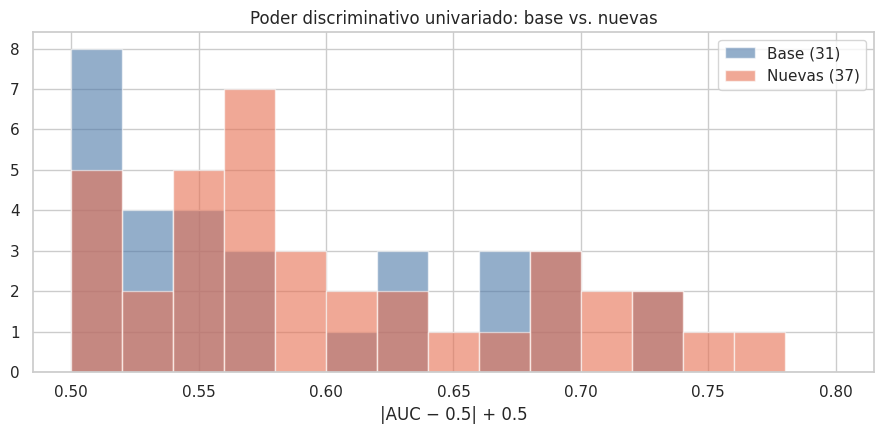

Mejores nuevas: rojez_std (0.77), rojez_p99 (0.75), rojizo_saturado (0.73), b_p95 (0.72), rojez_p95 (0.71)
Veredicto 3.4 → regresión logística 0.824 → 0.819; random forest 0.839 → 0.845. No hay mejora de AUC en esta base: las diferencias están dentro del error entre pliegues; el valor de las nuevas variables se evalúa en la selección (sección 7).


In [10]:
FE_COLS = BASE + NEW + LOCAL + ORD
SKEW_TH = 1.0     # mismo umbral de asimetría que el EDA (|asimetría| > 1)

def skew_cols(cols, ref=None):
    ref = TRAIN if ref is None else ref
    sk = ref[cols].skew()
    return [c for c in cols if abs(sk[c]) > SKEW_TH and ref[c].nunique() > 10]

def make_prep(cols, yj=True):
    sc = skew_cols(cols) if yj else []
    parts = []
    if sc: parts.append(("yj", PowerTransformer("yeo-johnson", standardize=True), sc))
    parts.append(("std", StandardScaler(), [c for c in cols if c not in sc]))
    return ColumnTransformer(parts, verbose_feature_names_out=False).set_output(transform="pandas")

LR = LogisticRegression(max_iter=3000, class_weight="balanced")
RF = RandomForestClassifier(200, class_weight="balanced_subsample", min_samples_leaf=2, random_state=SEED, n_jobs=-1)

def puntuar(m, X):
    return m.predict_proba(X)[:, 1] if hasattr(m, "predict_proba") else m.decision_function(X)

def cv_auc(model, X, y, groups, reps=3, n_splits=5):
    """AUC medio y desviación en CV estratificada y agrupada (repetida). X y y deben tener índice 0..n-1."""
    out = []
    for r in range(reps):
        for a, b in StratifiedGroupKFold(n_splits, shuffle=True, random_state=SEED + r).split(X, y, groups):
            m = clone(model).fit(X.iloc[a], y.iloc[a])
            out.append(roc_auc_score(y.iloc[b], puntuar(m, X.iloc[b])))
    return float(np.mean(out)), float(np.std(out))

yT, gT = TRAIN.y, TRAIN.grupo
filas = []
for nom, cols in [("A. Solo características base", BASE), ("B. Base + derivadas + bins", BASE + NEW + ORD), ("C. Base + derivadas + bins + locales", FE_COLS)]:
    for mn, mod in [("Regresión logística", LR), ("Random forest", RF)]:
        m, s = cv_auc(Pipeline([("prep", make_prep(cols)), ("clf", mod)]), TRAIN[cols], yT, gT)
        filas.append({"conjunto": nom, "modelo": mn, "n_features": len(cols), "AUC_CV": m, "desv": s})
cmp_fe = pd.DataFrame(filas)
display(cmp_fe.round(3))

# Relevancia univariada: nuevas vs. base
rel_new = pd.Series({f: auc_u(TRAIN[f], TRAIN.y) for f in NEW + LOCAL}); rel_new = (rel_new - .5).abs() + .5
rb = (rel_base - .5).abs() + .5
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(rb, bins=np.linspace(.5, .8, 16), alpha=.6, label=f"Base ({len(BASE)})", color="#4c78a8")
ax.hist(rel_new, bins=np.linspace(.5, .8, 16), alpha=.6, label=f"Nuevas ({len(NEW) + len(LOCAL)})", color="#e76f51")
ax.set_xlabel("|AUC − 0.5| + 0.5"); ax.legend(); ax.set_title("Poder discriminativo univariado: base vs. nuevas")
plt.tight_layout(); plt.show()
print("Mejores nuevas:", ", ".join(f"{k} ({v:.2f})" for k, v in rel_new.sort_values(ascending=False).head(5).items()))
lrA, lrC, rfA, rfC = cmp_fe.iloc[0].AUC_CV, cmp_fe.iloc[4].AUC_CV, cmp_fe.iloc[1].AUC_CV, cmp_fe.iloc[5].AUC_CV
print(f"Veredicto 3.4 → regresión logística {lrA:.3f} → {lrC:.3f}; random forest {rfA:.3f} → {rfC:.3f}. "
      + ("Las nuevas características mejoran el rendimiento." if (lrC - lrA >= .01 or rfC - rfA >= .01) else
         "No hay mejora de AUC en esta base: las diferencias están dentro del error entre pliegues; el valor de las nuevas variables se evalúa en la selección (sección 7)."))

## 4. Codificación de variables categóricas
La clase se codifica como etiqueta (bueno = 0, malo = 1), con malo como clase positiva porque el recall sobre ella es la métrica que manda: un falso negativo es un fruto defectuoso aceptado.

Los bins tamano_ord y rojizo_ord se dejan como ordinales (0 < 1 < 2) porque su orden es real (pequeño < mediano < grande; sin < leve < marcado) y es lo que verifica la tendencia monótona de Spearman con la clase. One-hot triplicaría las columnas y solo se justificaría si el patrón no fuera monótono.

El tipo de defecto, si existiera, es nominal y se codificaría con one-hot agrupando categorías raras. Nunca sería predictor, porque equivale a la etiqueta y causaría fuga; serviría como objetivo secundario. Los identificadores (crop_id, grupo, n_img) se descartan como características, ya que codificarlos haría memorizar el archivo o la sesión; grupo se usa solo para validar. El periodo de captura se emplea únicamente como diagnóstico, por el mismo riesgo de confundirse con la sesión.

| Variable | Tipo | Técnica | Justificación |
|---|---|---|---|
| `clase` (objetivo) | binaria | **Etiqueta**: bueno = 0, malo = 1 (en el CSV `good`/`bad`) | La clase de interés es *malo* (clase positiva): el recall sobre ella manda en las métricas |
| `tamano_ord`, `rojizo_ord` | ordinal (3 niveles) | **Ordinal** (0 < 1 < 2) | El orden pequeño < mediano < grande (y sin < leve < marcado) es real; se comprueba con la tendencia monótona respecto a la clase. One-hot triplicaría columnas |
| `defecto` | nominal | **One-hot** con agrupación de categorías raras (< 10 recortes → `otros`), solo si la columna existe | No hay orden entre defectos. **No es predictor** (sería fuga de la etiqueta): se usaría como objetivo secundario. *La v2 del CSV no lo trae* |
| `crop_id`, `grupo`, `n_img` | identificadores | **Descartadas** como característica; `grupo` solo como grupo de validación | Codificarlas (one-hot/target) memorizaría el archivo o la sesión |
| `periodo` de captura | ordinal | Solo diagnóstico, **no** predictor | Riesgo de confusión con la sesión de captura |

In [11]:
# --- Etiqueta del objetivo ---
enc_y = {"bueno": 0, "malo": 1}
assert (datos.clase.map(enc_y) == datos.y).all()
print("Codificación del objetivo:", enc_y)

# --- Ordinales: ¿el orden codificado tiene sentido? Tendencia monótona con la clase (Spearman, solo train) ---
filas = []
for v in ORD:
    r_, p_ = stats.spearmanr(TRAIN[v], TRAIN.y)
    filas.append({"variable": v, "rho_Spearman_con_malo": r_, "p": p_})
display(pd.DataFrame(filas).set_index("variable").round(4))
for f_ in filas:
    print(f"{f_['variable']}: ρ = {f_['rho_Spearman_con_malo']:.2f}, p = {f_['p']:.3g} → "
          + ("tendencia monótona significativa: el orden ordinal es informativo." if f_['p'] < .05 else
             "tendencia débil/no significativa: se conserva ordinal por su significado físico, pero aporta poco por sí sola."))
display(pd.concat({v: pd.crosstab(TRAIN[v], TRAIN.clase, normalize="index").mul(100).round(1).add_prefix("% ") for v in ORD}))
oh = OneHotEncoder(sparse_output=False).fit(TRAIN[["tamano_ord"]])
print("Alternativa one-hot del calibre:", list(oh.get_feature_names_out()), "→ 3 columnas en lugar de 1. Al conservarse el orden, la codificación ordinal resume la misma información en una sola columna (el one-hot solo sería preferible si el patrón fuera no monótono).")

# --- Tipo de defecto (solo si la base lo trae) ---
if HAY_DEFECTO:
    for d_ in (TRAIN, VAL, TEST, datos):
        d_["defecto"] = d_["defecto"].fillna("ninguno")
    ct = pd.crosstab(TRAIN.defecto, TRAIN.clase)
    cramer = np.sqrt(stats.chi2_contingency(ct)[0] / (ct.values.sum() * (min(ct.shape) - 1)))
    print(f"V de Cramér entre defecto y clase = {cramer:.2f} → defecto ≈ clase: usarlo como predictor sería fuga de la etiqueta.")
    ohe = OneHotEncoder(min_frequency=10, handle_unknown="infrequent_if_exist", sparse_output=False).fit(TRAIN[["defecto"]])
    cols_ohe = [c.replace("defecto_", "def_").replace("infrequent_sklearn", "otros") for c in ohe.get_feature_names_out()]
    def codificar_defecto(d):
        return pd.DataFrame(ohe.transform(d[["defecto"]]), columns=cols_ohe, index=d.index).astype(int)
    display(codificar_defecto(TRAIN).sum().to_frame("n en train").T)
else:
    ohe = None
    def codificar_defecto(d):
        return pd.DataFrame(index=d.index)
    print("La v2 de etiquetas.csv no incluye el tipo de defecto: no hay variable nominal que codificar con one-hot. "
          "El código queda listo para cuando se agregue (columna `defecto`).")

# --- Periodo de captura (diagnóstico): tercil del número de imagen ---
datos["periodo"] = pd.qcut(datos.n_img, 3, labels=[0, 1, 2]).astype(int)
tp = pd.crosstab(datos.periodo, datos.clase); chi_p = stats.chi2_contingency(tp)[1]
display(tp.assign(pct_malo=(tp.malo / tp.sum(axis=1) * 100).round(1)))
print(f"Chi² periodo × clase: p = {chi_p:.3g} → " + ("la clase depende del periodo de captura: NO se usa como predictor y se vigilará (validación agrupada por bloques)." if chi_p < .05 else "sin evidencia de dependencia; igualmente no se usa como predictor."))

Codificación del objetivo: {'bueno': 0, 'malo': 1}


,rho_Spearman_con_malo,p
variable,,
tamano_ord,0.1161,0.0625
rojizo_ord,0.3642,0.0000


tamano_ord: ρ = 0.12, p = 0.0625 → tendencia débil/no significativa: se conserva ordinal por su significado físico, pero aporta poco por sí sola.
rojizo_ord: ρ = 0.36, p = 1.65e-09 → tendencia monótona significativa: el orden ordinal es informativo.


clase                  % bueno  % malo
           tamano_ord                 
tamano_ord 0              69.8    30.2
           1              63.9    36.1
           2              56.2    43.8
rojizo_ord 0              82.6    17.4
           1              67.4    32.6
           2              39.5    60.5

Alternativa one-hot del calibre: ['tamano_ord_0', 'tamano_ord_1', 'tamano_ord_2'] → 3 columnas en lugar de 1. Al conservarse el orden, la codificación ordinal resume la misma información en una sola columna (el one-hot solo sería preferible si el patrón fuera no monótono).
La v2 de etiquetas.csv no incluye el tipo de defecto: no hay variable nominal que codificar con one-hot. El código queda listo para cuando se agregue (columna `defecto`).


clase,bueno,malo,pct_malo
periodo,,,
0,82,36,30.5
1,67,50,42.7
2,73,45,38.1


Chi² periodo × clase: p = 0.146 → sin evidencia de dependencia; igualmente no se usa como predictor.


## 5. Transformación: sesgo y normalidad
Muchas características son asimétricas (pct_*, nitidez, razones de canales). Una cola larga domina la escala y perjudica a los modelos lineales, de distancia y a las pruebas paramétricas (ANOVA, PCA, FA). Se comparan, solo con entrenamiento, log(1+x) y raíz cuadrada (simples, pero exigen x ≥ 0), Box–Cox (ajusta λ, pero exige x > 0) y Yeo–Johnson, que generaliza a ceros y negativos (como a_medio o ind_azul). Se transforman las variables con |asimetría| > 1, el umbral del EDA, y se evalúa cuánto reduce cada técnica el sesgo.

In [12]:
sk0 = TRAIN[FE_COLS].skew()
sesg = [c for c in FE_COLS if abs(sk0[c]) > SKEW_TH and TRAIN[c].nunique() > 10]
print(f"{len(sesg)} de {len(FE_COLS)} características con |asimetría| > {SKEW_TH}")

filas = []
for f in sesg:
    x = TRAIN[f].astype(float).values
    r = {"caracteristica": f, "min": x.min(), "asim_original": stats.skew(x)}
    r["log1p"] = stats.skew(np.log1p(x)) if x.min() >= 0 else np.nan
    r["raiz"] = stats.skew(np.sqrt(x)) if x.min() >= 0 else np.nan
    pt_ = lambda m: stats.skew(PowerTransformer(m, standardize=True).fit_transform(x.reshape(-1, 1)).ravel())
    r["box-cox"] = pt_("box-cox") if x.min() > 0 else np.nan
    r["yeo-johnson"] = pt_("yeo-johnson")
    filas.append(r)
tsk = pd.DataFrame(filas).set_index("caracteristica")
met = ["log1p", "raiz", "box-cox", "yeo-johnson"]
tsk["mejor"] = tsk[met].abs().idxmin(axis=1)
display(tsk.round(2))
resumen = pd.DataFrame({"|asimetría| media": [tsk.asim_original.abs().mean()] + [tsk[m].abs().mean() for m in met],
                        "aplicable a": [len(tsk)] + [int(tsk[m].notna().sum()) for m in met],
                        "mejor en": [""] + [int((tsk.mejor == m).sum()) for m in met]}, index=["original"] + met)
display(resumen.round(2))

25 de 70 características con |asimetría| > 1.0


,min,asim_original,log1p,raiz,box-cox,yeo-johnson,mejor
caracteristica,,,,,,,
solidez,0.76,-1.41,-1.50,-1.50,-0.09,-0.08,yeo-johnson
matiz,213.14,3.31,3.09,3.20,NaN,2.08,yeo-johnson
a_medio,-0.55,1.98,NaN,NaN,NaN,-0.01,yeo-johnson
fondo_brillo,210.00,-5.68,-5.90,-5.79,0.47,0.47,box-cox
pct_rojizo,0.00,3.48,3.12,1.17,NaN,0.64,yeo-johnson
pct_marron,0.00,2.48,2.45,1.22,NaN,0.91,yeo-johnson
pct_palido,0.00,1.59,1.49,0.55,NaN,0.26,yeo-johnson
pct_oscuro,0.00,1.17,0.98,0.31,-0.11,0.22,box-cox
mancha_max,0.00,2.33,2.14,0.96,NaN,0.39,yeo-johnson


,|asimetría| media,aplicable a,mejor en
original,2.14,25,
log1p,1.89,20,0
raiz,1.47,20,0
box-cox,0.13,13,8
yeo-johnson,0.34,25,17


**Decisión**. Se adopta Yeo–Johnson porque es la única sin restricciones de signo y, según la columna mejor de la tabla, reduce la asimetría en la mayoría de los casos. Su λ se aprende en entrenamiento y se reutiliza en validación y prueba. Las variables ya simétricas no se transforman, para conservar su interpretación. Cuando hay una masa de ceros (pct_rojizo) ninguna transformación monótona la elimina, y por eso existe hay_rojizo. La CNN no usa esta transformación: consume píxeles escalados (sección 8).

Asimetría media |a|: 2.15 → 0.25


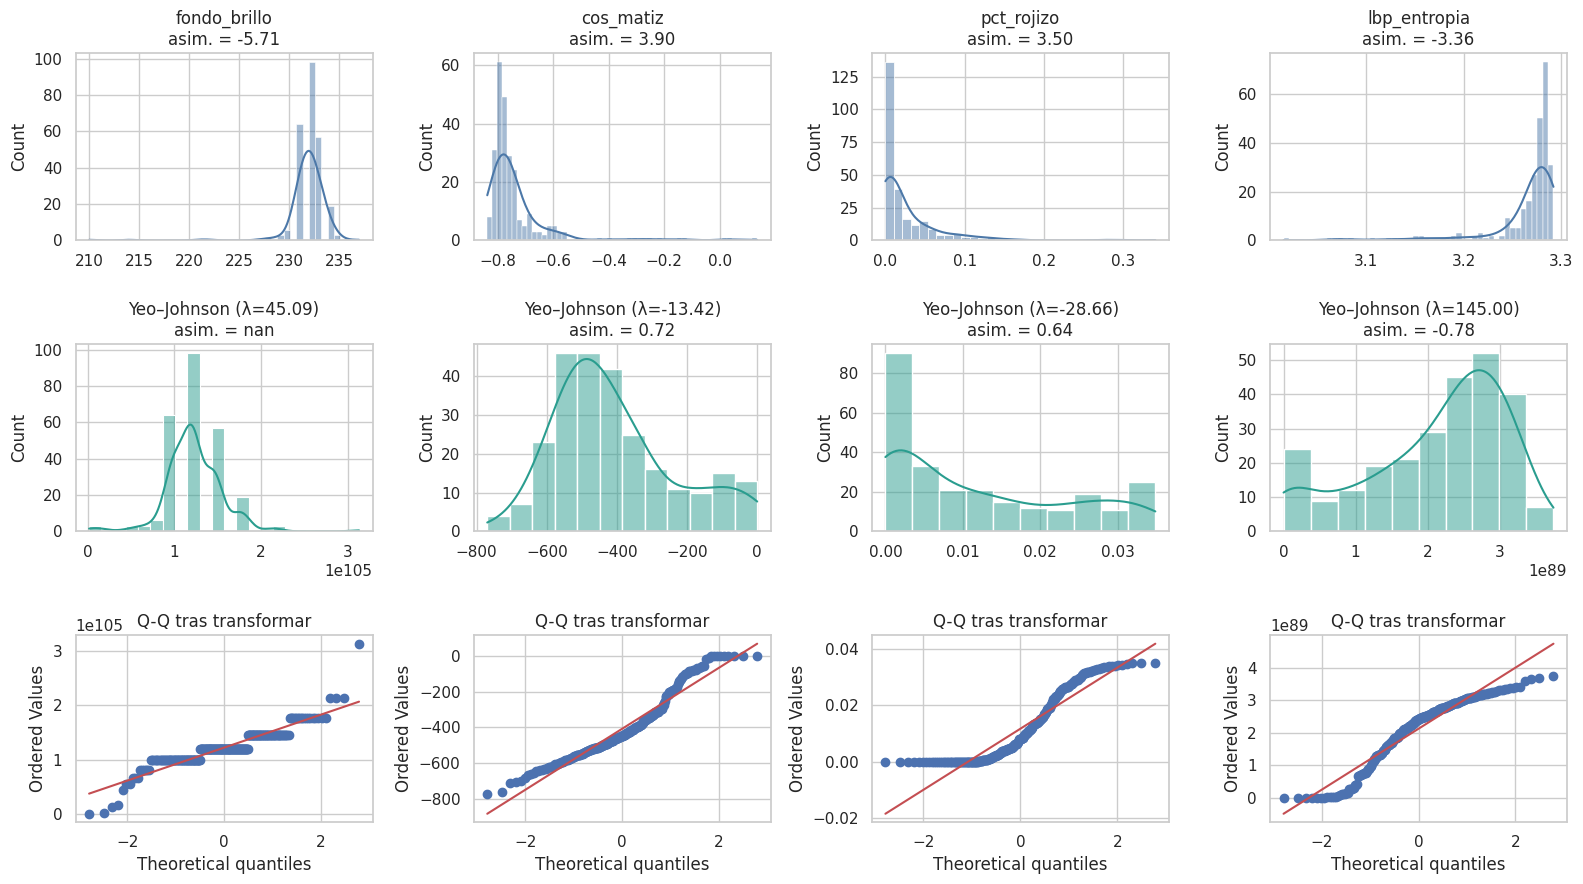

Siguen con |asimetría| > 1 tras la transformación (masa de ceros/colas extremas): ninguna
Normales (p > 0.05) antes: 0 de 25 → después: 13


In [13]:
pt = PowerTransformer("yeo-johnson", standardize=False).fit(TRAIN[sesg])
tr_yj = pd.DataFrame(pt.transform(TRAIN[sesg]), columns=sesg)
comp = pd.DataFrame({"antes": TRAIN[sesg].skew(), "después": tr_yj.skew(), "lambda": pt.lambdas_}, index=sesg)
print(f"Asimetría media |a|: {comp.antes.abs().mean():.2f} → {comp['después'].abs().mean():.2f}")

top = comp.antes.abs().sort_values(ascending=False).index[:4]
fig, axs = plt.subplots(3, 4, figsize=(16, 9))
for j, f in enumerate(top):
    sns.histplot(TRAIN[f], kde=True, ax=axs[0, j], color="#4c78a8"); axs[0, j].set_title(f"{f}\nasim. = {comp.loc[f, 'antes']:.2f}")
    sns.histplot(tr_yj[f], kde=True, ax=axs[1, j], color="#2a9d8f"); axs[1, j].set_title(f"Yeo–Johnson (λ={comp.loc[f, 'lambda']:.2f})\nasim. = {comp.loc[f, 'después']:.2f}")
    stats.probplot(tr_yj[f], dist="norm", plot=axs[2, j]); axs[2, j].set_title("Q-Q tras transformar")
    for a_ in axs[:2, j]: a_.set_xlabel("")
plt.tight_layout(); plt.show()
no_corr = comp[comp["después"].abs() > 1].index.tolist()
print("Siguen con |asimetría| > 1 tras la transformación (masa de ceros/colas extremas):", no_corr or "ninguna")

# Prueba formal de normalidad (D'Agostino-Pearson)
from scipy.stats import normaltest
nt = pd.DataFrame({"p antes": [normaltest(TRAIN[f])[1] for f in sesg],
                   "p después": [normaltest(tr_yj[f])[1] for f in sesg]}, index=sesg)
print(f"Normales (p > 0.05) antes: {(nt['p antes'] > .05).sum()} de {len(sesg)} → después: {(nt['p después'] > .05).sum()}")

## 6. Escalamiento y convergencia
Las variables tienen unidades y rangos muy distintos (brillo del fondo ≈ 200, nitidez en miles, proporciones en [0, 1], radio ≈ 360 px). Sin escalar, las de mayor magnitud dominan la distancia (kNN, SVM) y el gradiente (regresión logística), la optimización converge más lento y la regularización penaliza de forma desigual. Se comparan cuatro tratamientos: Min–Max (rango [0, 1], sensible a atípicos, requerido por χ²), Robust (mediana e IQR, resistente a atípicos que aquí no se eliminan por ser defectos reales), estandarización (media 0 y desviación 1, estándar para modelos lineales, kNN, SVM, PCA y FA) y Yeo–Johnson + estandarización, que añade la corrección de asimetría.

Antes de escalar: la desviación estándar va de 0.00032 a 4.8e+02 (razón 1.5e+06).
Después de Yeo–Johnson + estandarización (train): desviación = [1. 0.] | media máx. |μ| = 0.0


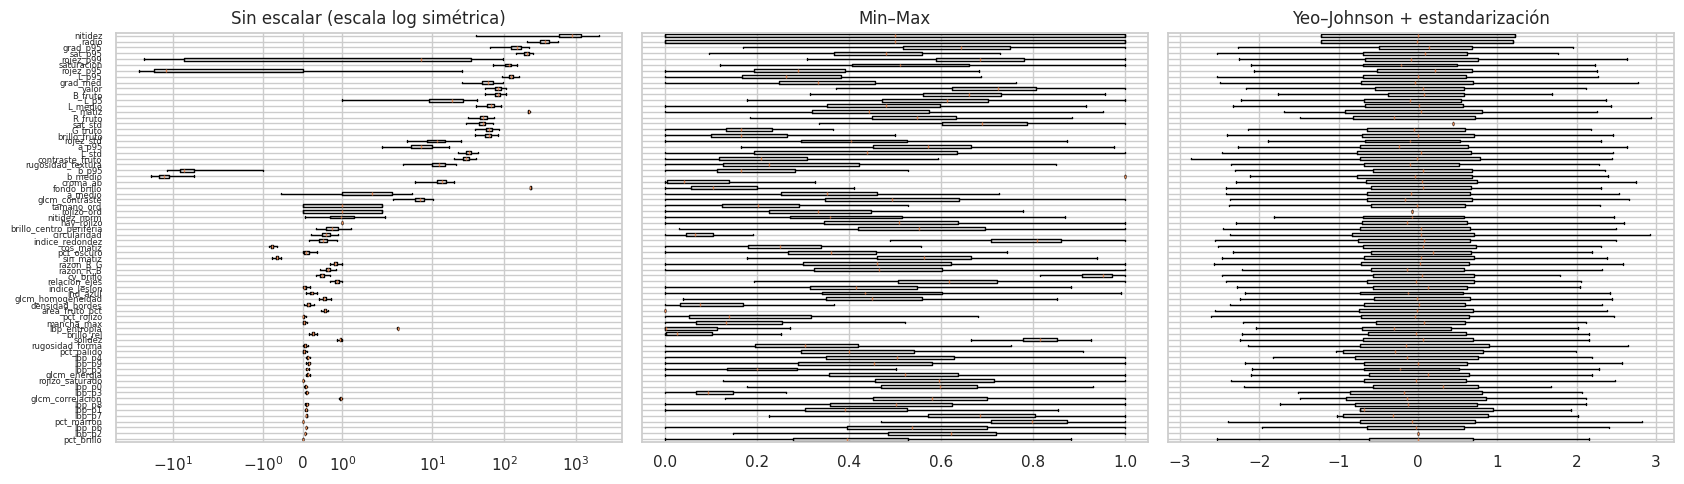

In [14]:
rng_tab = pd.DataFrame({"min": TRAIN[FE_COLS].min(), "max": TRAIN[FE_COLS].max(), "desv": TRAIN[FE_COLS].std()})
print(f"Antes de escalar: la desviación estándar va de {rng_tab.desv.min():.2g} a {rng_tab.desv.max():.2g} (razón {rng_tab.desv.max() / rng_tab.desv.min():.1e}).")

prep_final = make_prep(FE_COLS).fit(TRAIN[FE_COLS])
Z_tr = prep_final.transform(TRAIN[FE_COLS])
print("Después de Yeo–Johnson + estandarización (train): desviación =", Z_tr.std().round(2).unique(), "| media máx. |μ| =", round(float(Z_tr.mean().abs().max()), 3))

fig, axs = plt.subplots(1, 3, figsize=(17, 5), sharey=False)
cols_show = TRAIN[FE_COLS].std().sort_values().index
axs[0].boxplot([TRAIN[c] for c in cols_show], vert=False, showfliers=False); axs[0].set_xscale("symlog")
axs[0].set_yticklabels(cols_show, fontsize=6); axs[0].set_title("Sin escalar (escala log simétrica)")
mm = MinMaxScaler().fit_transform(TRAIN[FE_COLS]); rb_ = RobustScaler().fit_transform(TRAIN[FE_COLS])
axs[1].boxplot(mm, vert=False, showfliers=False); axs[1].set_yticklabels([]); axs[1].set_title("Min–Max")
axs[2].boxplot(Z_tr.values, vert=False, showfliers=False); axs[2].set_yticklabels([]); axs[2].set_title("Yeo–Johnson + estandarización")
plt.tight_layout(); plt.show()

### 6.1 Efecto sobre la convergencia y el rendimiento
Se mide cuántas iteraciones necesita la regresión logística (L-BFGS) y si converge con el límite por defecto de 100, y el AUC en validación cruzada de cuatro modelos con cada tratamiento. El random forest sirve de control: al basarse en umbrales no debería cambiar.

In [15]:
trat = {"Sin escalar": lambda cols: "passthrough",
        "Min–Max": lambda cols: MinMaxScaler(),
        "Robust": lambda cols: RobustScaler(),
        "Estandarización": lambda cols: StandardScaler(),
        "Yeo–Johnson + estand.": lambda cols: make_prep(cols)}

conv = []
for nom, f in trat.items():
    Xm = TRAIN[FE_COLS] if nom == "Sin escalar" else (f(FE_COLS).fit_transform(TRAIN[FE_COLS]))
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        t0 = time.perf_counter(); m = LogisticRegression(max_iter=100, class_weight="balanced").fit(Xm, yT); dt = time.perf_counter() - t0
    conv.append({"tratamiento": nom, "iteraciones_LR": int(m.n_iter_[0]), "convergió en ≤100 iter.": not any(issubclass(x.category, ConvergenceWarning) for x in w),
                 "tiempo_ajuste_ms": dt * 1000})
conv = pd.DataFrame(conv).set_index("tratamiento"); display(conv.round(1))

modelos = {"Reg. logística": LR, "kNN (k=15)": KNeighborsClassifier(15), "SVM RBF": SVC(class_weight="balanced"), "Random forest": RF}
res = {}
for nom, f in trat.items():
    res[nom] = {}
    for mn, mod in modelos.items():
        m, s = cv_auc(Pipeline([("esc", f(FE_COLS)), ("clf", mod)]), TRAIN[FE_COLS], yT, gT, reps=2)
        res[nom][mn] = m
tab_esc = pd.DataFrame(res).T
display(tab_esc.round(3).style.background_gradient(cmap="YlGn", axis=0))

,iteraciones_LR,convergió en ≤100 iter.,tiempo_ajuste_ms
tratamiento,,,
Sin escalar,100,False,392.7
Min–Max,26,True,18.7
Robust,58,True,41.3
Estandarización,55,True,35.8
Yeo–Johnson + estand.,59,True,35.9


,Reg. logística,kNN (k=15),SVM RBF,Random forest
Sin escalar,0.843000,0.630000,0.677000,0.862000
Min–Max,0.835000,0.804000,0.841000,0.862000
Robust,0.837000,0.812000,0.865000,0.861000
Estandarización,0.833000,0.805000,0.863000,0.861000
Yeo–Johnson + estand.,0.825000,0.810000,0.867000,0.849000


### 6.2 Decisión

In [16]:
mejor_lin = tab_esc[["Reg. logística", "kNN (k=15)", "SVM RBF"]].mean(axis=1)
sin, yj = mejor_lin["Sin escalar"], mejor_lin["Yeo–Johnson + estand."]
it_sin, it_yj = conv.loc["Sin escalar", "iteraciones_LR"], conv.loc["Yeo–Johnson + estand.", "iteraciones_LR"]
display(mejor_lin.rename("AUC medio (reg. logística, kNN, SVM)").to_frame().round(3))
display(Markdown(
    f"- **Convergencia.** La regresión logística pasa de **{it_sin}** iteraciones sin escalar (¿convergió con el límite de 100? "
    f"**{'sí' if conv.loc['Sin escalar', 'convergió en ≤100 iter.'] else 'no'}**) a **{it_yj}** con Yeo–Johnson + estandarización "
    f"(¿convergió? **{'sí' if conv.loc['Yeo–Johnson + estand.', 'convergió en ≤100 iter.'] else 'no'}**).\n"
    f"- **Rendimiento.** Escalar es imprescindible para los modelos sensibles a la escala: el AUC medio sube de {sin:.3f} (sin escalar) a {yj:.3f} (Yeo–Johnson + estandarización). "
    f"El mejor tratamiento fue **{mejor_lin.idxmax()}** ({mejor_lin.max():.3f}); Yeo–Johnson + estandarización queda a {mejor_lin.max() - yj:.3f}, {'diferencia dentro del ruido de la validación cruzada' if mejor_lin.max() - yj < .03 else 'diferencia apreciable, aunque se prioriza corregir la asimetría que requieren ANOVA, PCA y FA'}. "
    f"El *random forest* varía de {tab_esc['Random forest'].min():.3f} a {tab_esc['Random forest'].max():.3f} (≈ constante, como se esperaba de un modelo basado en umbrales).\n\n"
    f"**Decisión.** Se adopta **Yeo–Johnson + estandarización**. El rendimiento es equivalente al de los mejores escaladores, y además corrige la asimetría (objetivo 2.4), "
    f"deja todas las variables con media 0 y desviación 1 para que contribuyan por igual y es la entrada que requieren las técnicas siguientes (ANOVA, PCA, FA, que suponen aproximadamente normalidad y varianzas comparables). "
    f"Min–Max se usa **solo** de forma auxiliar para χ² (necesita valores no negativos) y para la prueba de varianza; Robust sería una alternativa válida si se prefiriera no transformar."))

,"AUC medio (reg. logística, kNN, SVM)"
Sin escalar,0.716
Min–Max,0.827
Robust,0.838
Estandarización,0.834
Yeo–Johnson + estand.,0.834


- **Convergencia.** La regresión logística pasa de **100** iteraciones sin escalar (¿convergió con el límite de 100? **no**) a **59** con Yeo–Johnson + estandarización (¿convergió? **sí**).
- **Rendimiento.** Escalar es imprescindible para los modelos sensibles a la escala: el AUC medio sube de 0.716 (sin escalar) a 0.834 (Yeo–Johnson + estandarización). El mejor tratamiento fue **Robust** (0.838); Yeo–Johnson + estandarización queda a 0.004, diferencia dentro del ruido de la validación cruzada. El *random forest* varía de 0.849 a 0.862 (≈ constante, como se esperaba de un modelo basado en umbrales).

**Decisión.** Se adopta **Yeo–Johnson + estandarización**. El rendimiento es equivalente al de los mejores escaladores, y además corrige la asimetría (objetivo 2.4), deja todas las variables con media 0 y desviación 1 para que contribuyan por igual y es la entrada que requieren las técnicas siguientes (ANOVA, PCA, FA, que suponen aproximadamente normalidad y varianzas comparables). Min–Max se usa **solo** de forma auxiliar para χ² (necesita valores no negativos) y para la prueba de varianza; Robust sería una alternativa válida si se prefiriera no transformar.

## 7. Selección (filtros) y extracción de características
Con unas 70 candidatas y pocos cientos de recortes de entrenamiento, el riesgo de sobreajuste es alto. Se usan filtros (independientes del modelo, baratos y reproducibles) para quitar redundancia y ruido, y extracción (PCA, FA) para resumir la información en pocas variables latentes. Los filtros supervisados se ajustan con entrenamiento y, al compararlos, dentro de cada pliegue.

### 7.1 Umbral de varianza
Elimina las características casi constantes, que no pueden discriminar. Como la varianza depende de la escala, se calcula sobre las variables llevadas a [0, 1] con Min–Max. Además se descartan las que tienen más del 95 % de los recortes con el mismo valor. Es un filtro no supervisado, así que usar todo el entrenamiento no genera fuga.

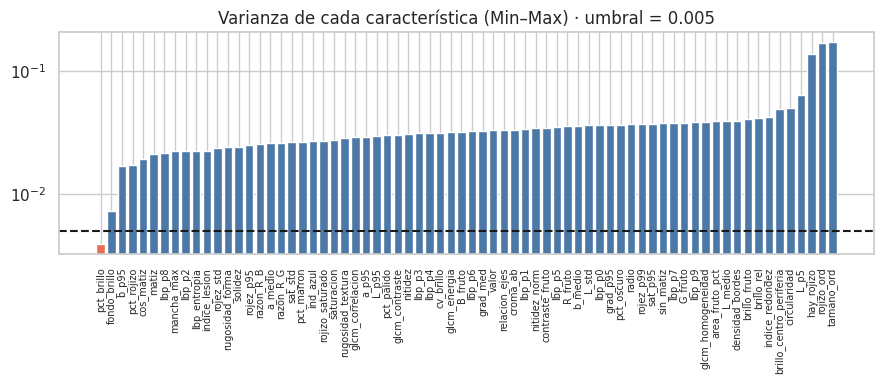

Varianza por debajo del umbral: ['pct_brillo']
Casi constantes (>95 % de un mismo valor): ['pct_brillo']
Eliminadas: ['pct_brillo']
70 → 69 candidatas


In [17]:
VAR_TH = 0.005
mm = MinMaxScaler().fit(TRAIN[FE_COLS]); V = pd.Series(mm.transform(TRAIN[FE_COLS]).var(axis=0), index=FE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(V.index, V.values, color=np.where(V.values < VAR_TH, "#e76f51", "#4c78a8")); ax.axhline(VAR_TH, ls="--", c="k")
ax.set_yscale("log"); ax.tick_params(axis="x", rotation=90, labelsize=7); ax.set_title(f"Varianza de cada característica (Min–Max) · umbral = {VAR_TH}")
plt.tight_layout(); plt.show()
baja_var = V[V < VAR_TH].index.tolist()
casi_cte = [c for c in FE_COLS if TRAIN[c].value_counts(normalize=True).iloc[0] > .95]
print("Varianza por debajo del umbral:", baja_var or "ninguna")
print("Casi constantes (>95 % de un mismo valor):", casi_cte or "ninguna")
baja_var = sorted(set(baja_var) | set(casi_cte), key=FE_COLS.index)
print("Eliminadas:", baja_var or "ninguna")
CAND = [c for c in FE_COLS if c not in baja_var]
print(f"{len(FE_COLS)} → {len(CAND)} candidatas")

### 7.2 Relevancia univariada: ANOVA, χ² e información mutua
Cada criterio mira la relación con la clase desde un ángulo distinto. ANOVA contrasta diferencias de medias (relación lineal, supone normalidad, de ahí la transformación previa). x² mide dependencia sobre variables no negativas (Min–Max). La información mutua captura dependencias no lineales sin suponer distribución, y el AUC de Mann–Whitney verifica que el ranking sea coherente con el EDA. Se promedian los rangos de los cuatro para obtener un consenso menos dependiente de los supuestos de un solo método.

In [18]:
def bh(p):
    """Ajuste de Benjamini–Hochberg (FDR)."""
    p = np.asarray(p); n = len(p); o = np.argsort(p); r = np.empty(n)
    r[o] = np.minimum.accumulate((p[o] * n / np.arange(1, n + 1))[::-1])[::-1]
    return np.clip(r, 0, 1)

Zc = make_prep(CAND).fit(TRAIN[CAND]).transform(TRAIN[CAND])          # Yeo–Johnson + estandarización (train)
Mc = MinMaxScaler().fit_transform(TRAIN[CAND])                        # no negativos, requisito de χ²
F, pF = f_classif(Zc, yT); F, pF = np.nan_to_num(F), np.nan_to_num(pF, nan=1.0)
X2, p2 = chi2(Mc, yT)
MI = mutual_info_classif(Zc, yT, random_state=SEED, n_neighbors=5)
rk = pd.DataFrame({"ANOVA_F": F, "p_ANOVA": pF, "chi2": X2, "p_chi2": p2, "info_mutua": MI,
                   "AUC_MW": [auc_u(TRAIN[c], yT) for c in CAND]}, index=CAND)
rk["|AUC-0.5|"] = (rk.AUC_MW - .5).abs()
rangos = rk[["ANOVA_F", "chi2", "info_mutua", "|AUC-0.5|"]].rank(ascending=False)
rk["rango_consenso"] = rangos.mean(axis=1)
rk = rk.sort_values("rango_consenso")
rk["p_ANOVA_BH"] = bh(rk.p_ANOVA.values)
display(rk.head(15).round(4))
print("Concordancia entre criterios (ρ de Spearman entre rangos):")
display(rangos.corr(method="spearman").round(2))
r_af = rangos.corr(method="spearman").loc["ANOVA_F", "chi2"]
print(f"ρ(ANOVA, χ²) = {r_af:.2f}: " + ("los criterios discrepan bastante (miden cosas distintas: diferencia de medias frente a dependencia sobre variables reescaladas), por eso se usa un consenso de rangos y no un solo criterio." if r_af < .5 else "los criterios coinciden en el ordenamiento."))
print(f"Significativas (ANOVA, p ajustado BH < 0.05): {(rk.p_ANOVA_BH < .05).sum()} de {len(rk)} · χ² (p < 0.05): {(rk.p_chi2 < .05).sum()} de {len(rk)}")

,ANOVA_F,p_ANOVA,chi2,p_chi2,info_mutua,AUC_MW,|AUC-0.5|,rango_consenso,p_ANOVA_BH
pct_marron,46.8399,0.0000,14.6066,0.0001,0.1091,0.7219,0.2219,4.250,0.0000
b_p95,32.9438,0.0000,2.9442,0.0862,0.0889,0.7221,0.2221,8.250,0.0000
rojizo_saturado,24.3332,0.0000,9.9608,0.0016,0.0629,0.7345,0.2345,9.250,0.0000
rojizo_ord,39.1390,0.0000,11.4046,0.0007,0.0402,0.7055,0.2055,10.500,0.0000
indice_lesion,30.3480,0.0000,4.3080,0.0379,0.0645,0.6820,0.1820,11.500,0.0000
nitidez,40.3327,0.0000,1.9585,0.1617,0.1200,0.6611,0.1611,12.000,0.0000
contraste_fruto,50.2760,0.0000,0.9993,0.3175,0.0968,0.6121,0.1121,16.000,0.0000
a_medio,15.2126,0.0001,2.1754,0.1402,0.0883,0.6321,0.1321,17.750,0.0004
pct_rojizo,18.4052,0.0000,7.4975,0.0062,0.0094,0.7261,0.2261,19.750,0.0001
matiz,28.1690,0.0000,2.6255,0.1052,0.0166,0.6324,0.1324,21.875,0.0000


Concordancia entre criterios (ρ de Spearman entre rangos):


,ANOVA_F,chi2,info_mutua,|AUC-0.5|
ANOVA_F,1.00,0.10,0.70,0.05
chi2,0.10,1.00,0.05,0.93
info_mutua,0.70,0.05,1.00,0.02
|AUC-0.5|,0.05,0.93,0.02,1.00


ρ(ANOVA, χ²) = 0.10: los criterios discrepan bastante (miden cosas distintas: diferencia de medias frente a dependencia sobre variables reescaladas), por eso se usa un consenso de rangos y no un solo criterio.
Significativas (ANOVA, p ajustado BH < 0.05): 33 de 69 · χ² (p < 0.05): 9 de 69


### 7.3 Correlación: redundancia
Las variables muy correlacionadas aportan la misma información, inflan la varianza de los coeficientes y alargan el entrenamiento. Con la correlación de Spearman (robusta a atípicos), se recorren las características de mayor a menor relevancia y se descarta toda la que tenga |ρ| ≥ 0.9 con una ya retenida. Así, de cada grupo de redundantes se conserva la más informativa.

|ρ| ≥ 0.9: se descartan 27 de 69 → quedan 42


,redundante con (retenida)
rojizo_ord,rojizo_saturado
pct_rojizo,rojizo_saturado
rojez_p99,rojizo_saturado
a_p95,a_medio
L_std,contraste_fruto
glcm_correlacion,rugosidad_textura
circularidad,indice_redondez
grad_med,nitidez
lbp_p5,lbp_p7
glcm_contraste,rugosidad_textura


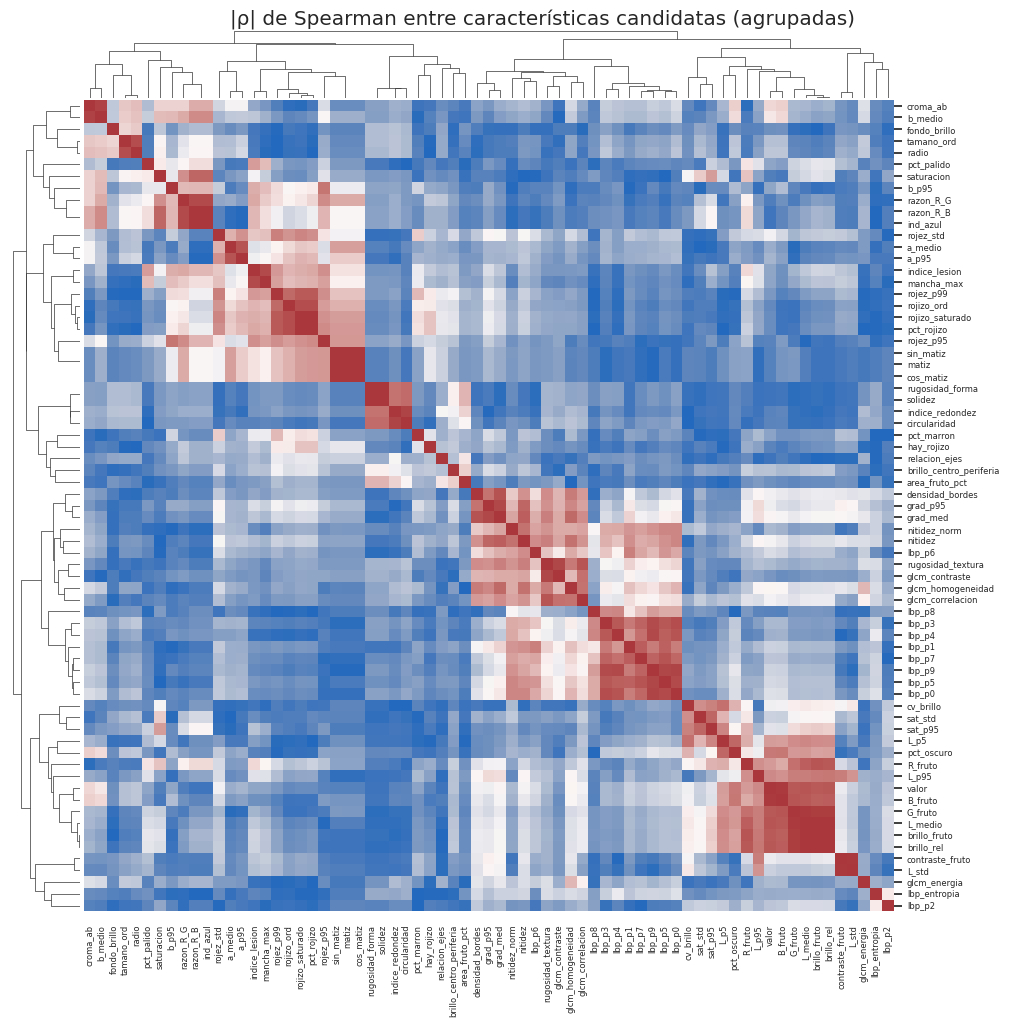

In [19]:
RHO = 0.9
rho = TRAIN[CAND].corr(method="spearman").abs()
orden_rel = rk.index.tolist(); keep_c, drop_c = [], {}
for f in orden_rel:
    par = [e for e in keep_c if rho.loc[f, e] >= RHO]
    if par: drop_c[f] = par[0]
    else: keep_c.append(f)
print(f"|ρ| ≥ {RHO}: se descartan {len(drop_c)} de {len(CAND)} → quedan {len(keep_c)}")
display(pd.Series(drop_c, name="redundante con (retenida)").to_frame())

ordc = sns.clustermap(rho.loc[keep_c + list(drop_c), keep_c + list(drop_c)], cmap="vlag", center=.5, figsize=(11, 11), cbar_pos=None,
                      xticklabels=True, yticklabels=True, dendrogram_ratio=.08)
ordc.ax_heatmap.tick_params(labelsize=6); ordc.figure.suptitle("|ρ| de Spearman entre características candidatas (agrupadas)", y=1.0)
plt.show()

### 7.4 ¿Cuántas características conservar? (curva de selección)
FiltroSeleccion combina los filtros anteriores: ordena por ANOVA F, descarta redundantes y conserva las k mejores. Se evalúa el AUC en validación cruzada agrupada para distintos k, con el filtro dentro de cada pliegue. Se elige el menor k cuyo AUC queda a ≤ 0.01 del máximo. Esa tolerancia es menor que el error entre pliegues, así que una diferencia menor no se distingue del ruido y conviene el modelo más simple. La regla 1-SE se reporta solo como referencia.

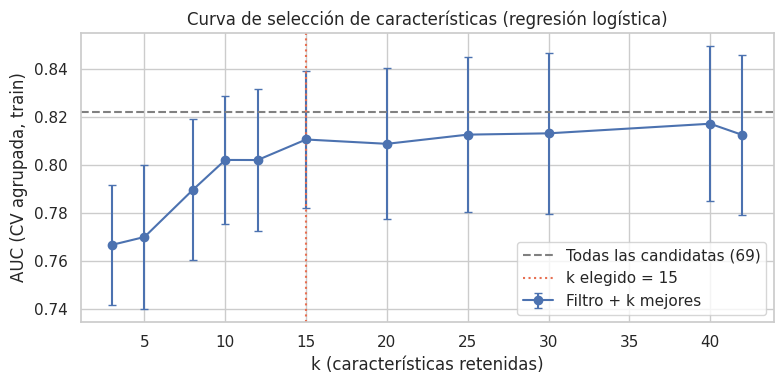

,k,AUC,desv
0,3,0.767,0.056
1,5,0.770,0.067
2,8,0.790,0.066
3,10,0.802,0.059
4,12,0.802,0.066
5,15,0.811,0.063
6,20,0.809,0.070
7,25,0.813,0.072
8,30,0.813,0.075
9,40,0.817,0.072


Máximo en k=40 (AUC=0.817) · error estándar ≈ 0.032 · tolerancia 0.01 → k = 15 (la regla 1-SE daría k = 8). Con todas las candidatas: AUC = 0.822.


In [20]:
class FiltroSeleccion(BaseEstimator, TransformerMixin):
    """Filtro supervisado: ranking por ANOVA F + descarte de redundantes (|rho| Spearman >= rho) + top-k."""
    def __init__(self, k=10, rho=0.9):
        self.k, self.rho = k, rho
    def fit(self, X, y):
        X = pd.DataFrame(X); F_, _ = f_classif(X, y)
        rel = pd.Series(np.nan_to_num(F_), index=X.columns).sort_values(ascending=False)
        r = X.corr(method="spearman").abs(); keep = []
        for c in rel.index:
            if all(r.loc[c, e] < self.rho for e in keep): keep.append(c)
            if len(keep) == self.k: break
        self.cols_, self.ranking_ = keep, rel
        return self
    def transform(self, X):
        return pd.DataFrame(X)[self.cols_]

KS = sorted({3, 5, 8, 10, 12, 15, 20, 25, 30, 40, len(keep_c)})
filas = []
for k in KS:
    pipe = Pipeline([("prep", make_prep(CAND)), ("fs", FiltroSeleccion(k, RHO)), ("clf", LR)])
    m, s = cv_auc(pipe, TRAIN[CAND], yT, gT, reps=3)
    filas.append({"k": k, "AUC": m, "desv": s})
curva = pd.DataFrame(filas)
base_todas = cv_auc(Pipeline([("prep", make_prep(CAND)), ("clf", LR)]), TRAIN[CAND], yT, gT, reps=3)
best = curva.loc[curva.AUC.idxmax()]; se = best.desv / np.sqrt(5); TOL = 0.01
K_SEL = int(curva[curva.AUC >= best.AUC - TOL].k.min())
K_1SE = int(curva[curva.AUC >= best.AUC - se].k.min())
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(curva.k, curva.AUC, yerr=curva.desv / np.sqrt(5), marker="o", capsize=3, label="Filtro + k mejores")
ax.axhline(base_todas[0], ls="--", c="gray", label=f"Todas las candidatas ({len(CAND)})"); ax.axvline(K_SEL, ls=":", c="#e76f51", label=f"k elegido = {K_SEL}")
ax.set_xlabel("k (características retenidas)"); ax.set_ylabel("AUC (CV agrupada, train)"); ax.legend(); ax.set_title("Curva de selección de características (regresión logística)")
plt.tight_layout(); plt.show()
display(curva.round(3))
print(f"Máximo en k={int(best.k)} (AUC={best.AUC:.3f}) · error estándar ≈ {se:.3f} · tolerancia {TOL} → k = {K_SEL} (la regla 1-SE daría k = {K_1SE}). Con todas las candidatas: AUC = {base_todas[0]:.3f}.")

In [21]:
fs_final = Pipeline([("prep", make_prep(CAND)), ("fs", FiltroSeleccion(K_SEL, RHO))]).fit(TRAIN[CAND], yT)
SEL = fs_final.named_steps["fs"].cols_
print(f"{len(FE_COLS)} características iniciales → {len(CAND)} (varianza) → {len(keep_c)} (correlación) → {len(SEL)} (ANOVA top-k)")
display(pd.DataFrame({"caracteristica": SEL, "origen": ["derivada" if c in NEW + ORD else "local" if c in LOCAL else "base" for c in SEL],
                      "consenso_rango": [rk.loc[c, "rango_consenso"] for c in SEL],
                      "AUC_MW": [rk.loc[c, "AUC_MW"] for c in SEL]}).round(3))

70 características iniciales → 69 (varianza) → 42 (correlación) → 15 (ANOVA top-k)


,caracteristica,origen,consenso_rango,AUC_MW
0,rojez_std,local,23.500,0.766
1,rojez_p99,local,22.000,0.753
2,pct_marron,base,4.250,0.722
3,b_p95,local,8.250,0.722
4,rojez_p95,local,25.500,0.709
5,rojizo_ord,derivada,10.500,0.705
6,grad_p95,local,22.750,0.705
7,rugosidad_textura,derivada,26.500,0.684
8,indice_lesion,derivada,11.500,0.682
9,glcm_homogeneidad,base,24.750,0.308


### 7.5 Extracción de características: PCA y análisis factorial
El PCA proyecta las variables en componentes ortogonales ordenados por varianza explicada, lo que resume la información y elimina la multicolinealidad. Es no supervisado, así que sus componentes de mayor varianza no son necesariamente los más discriminativos; por eso se compara contra el filtro.

El análisis factorial modela cada variable como combinación de pocos factores latentes más ruido; con rotación varimax los factores son interpretables (p. ej. un "factor color" y un "factor textura"). Antes se verifica su pertinencia con la prueba de Bartlett (¿la matriz de correlación difiere de la identidad?) y el KMO (> 0.6 es aceptable).

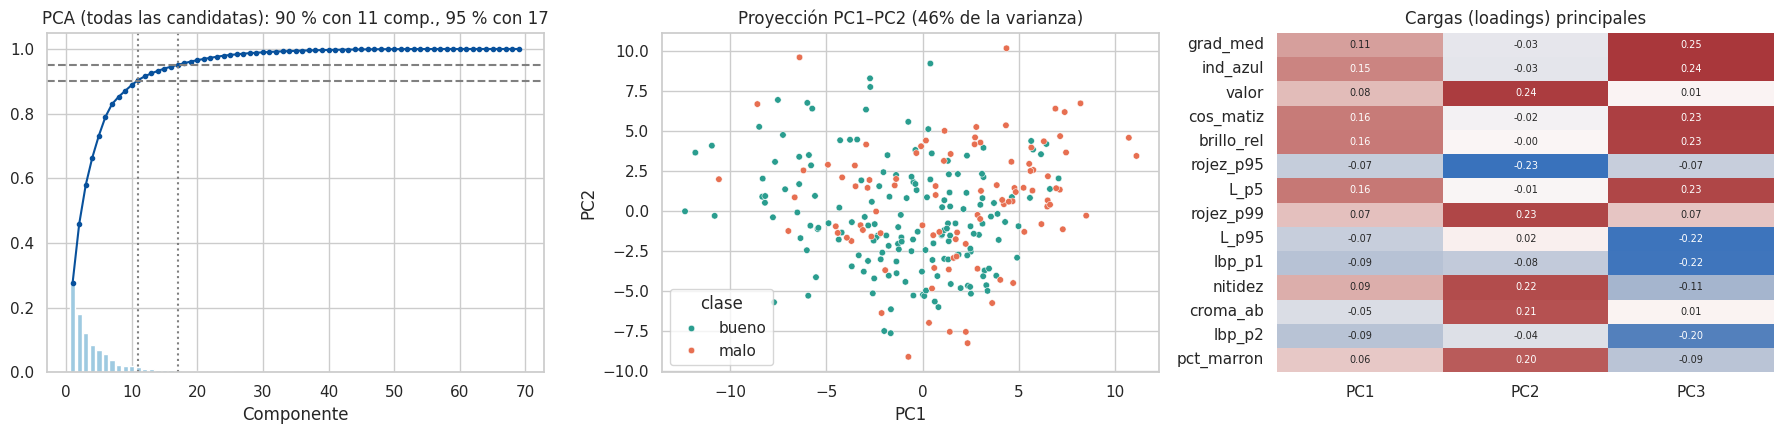

69 variables → 11 componentes (90 %) / 17 (95 %); criterio de Kaiser (autovalor > 1): 11.
PC1 se asocia a: nitidez_norm, lbp_p3, lbp_p4, indice_redondez, indice_lesion
PC2 se asocia a: valor, rojez_p95, rojez_p99, nitidez, croma_ab
PC3 se asocia a: grad_med, ind_azul, cos_matiz, brillo_rel, L_p5


In [22]:
pca = PCA(random_state=SEED).fit(Zc)
expl, cum = pca.explained_variance_ratio_, np.cumsum(pca.explained_variance_ratio_)
k80, k90, k95 = [int(np.searchsorted(cum, t) + 1) for t in (.80, .90, .95)]
kaiser = int((pca.explained_variance_ > 1).sum())

fig, axs = plt.subplots(1, 3, figsize=(18, 4.5))
axs[0].bar(range(1, len(expl) + 1), expl, color="#9ecae1"); axs[0].plot(range(1, len(expl) + 1), cum, "o-", c="#08519c", ms=3)
for t, kk in [(.90, k90), (.95, k95)]: axs[0].axhline(t, ls="--", c="gray"); axs[0].axvline(kk, ls=":", c="gray")
axs[0].set_title(f"PCA (todas las candidatas): 90 % con {k90} comp., 95 % con {k95}"); axs[0].set_xlabel("Componente")
sc = pd.DataFrame(pca.transform(Zc)[:, :2], columns=["PC1", "PC2"]).assign(clase=TRAIN.clase.values)
sns.scatterplot(data=sc, x="PC1", y="PC2", hue="clase", palette={"bueno": "#2a9d8f", "malo": "#e76f51"}, s=22, ax=axs[1])
axs[1].set_title(f"Proyección PC1–PC2 ({cum[1]:.0%} de la varianza)")
L = pd.DataFrame(pca.components_[:3].T, index=CAND, columns=["PC1", "PC2", "PC3"])
topL = L.abs().max(axis=1).sort_values(ascending=False).head(14).index
sns.heatmap(L.loc[topL], cmap="vlag", center=0, annot=True, fmt=".2f", annot_kws={"size": 7}, ax=axs[2], cbar=False); axs[2].set_title("Cargas (loadings) principales")
plt.tight_layout(); plt.show()
print(f"{len(CAND)} variables → {k90} componentes (90 %) / {k95} (95 %); criterio de Kaiser (autovalor > 1): {kaiser}.")
for pc in ["PC1", "PC2", "PC3"]:
    print(pc, "se asocia a:", ", ".join(L[pc].abs().sort_values(ascending=False).head(5).index))

Sobre las 15 características seleccionadas → Bartlett: χ²=4587, gl=105, p < 0.001 · KMO = 0.81 · factores por Kaiser: 3


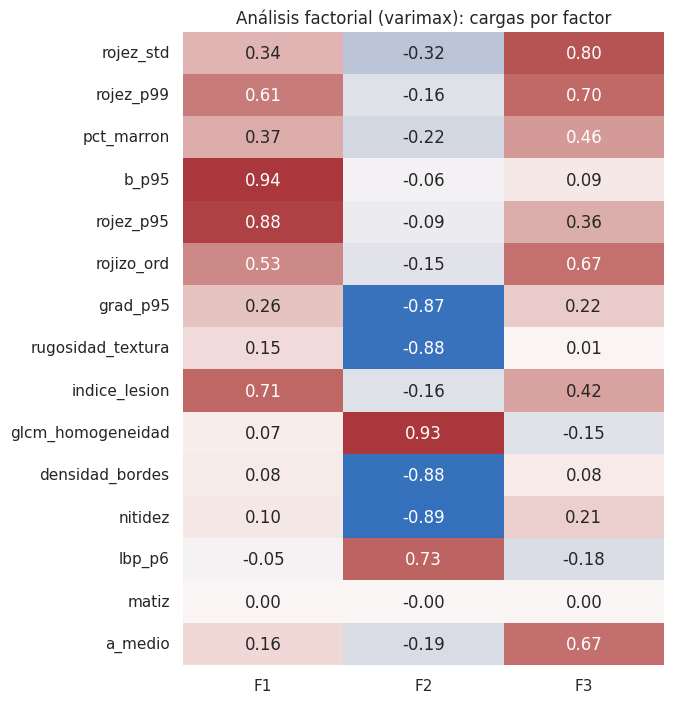

F1 ← b_p95, rojez_p95, indice_lesion, rojez_p99
F2 ← glcm_homogeneidad, nitidez, densidad_bordes, rugosidad_textura
F3 ← rojez_std, rojez_p99, a_medio, rojizo_ord


In [23]:
def bartlett(Z):
    n, p = Z.shape; R = np.corrcoef(Z.values, rowvar=False)
    chi = -(n - 1 - (2 * p + 5) / 6) * np.log(max(np.linalg.det(R), 1e-300)); df = p * (p - 1) / 2
    return chi, df, stats.chi2.sf(chi, df)

def kmo(Z):
    R = np.corrcoef(Z.values, rowvar=False); inv = np.linalg.pinv(R)
    P = -inv / np.sqrt(np.outer(np.diag(inv), np.diag(inv))); np.fill_diagonal(P, 0); R0 = R.copy(); np.fill_diagonal(R0, 0)
    return (R0 ** 2).sum() / ((R0 ** 2).sum() + (P ** 2).sum())

Zs = Zc[SEL]
chi_b, df_b, p_b = bartlett(Zs); kmo_g = kmo(Zs)
ev = np.sort(np.linalg.eigvalsh(np.corrcoef(Zs.values, rowvar=False)))[::-1]; K_FA = int((ev > 1).sum())
print(f"Sobre las {len(SEL)} características seleccionadas → Bartlett: χ²={chi_b:.0f}, gl={df_b:.0f}, p {'< 0.001' if p_b < .001 else f'= {p_b:.3f}'} · KMO = {kmo_g:.2f} · factores por Kaiser: {K_FA}")
fa = FactorAnalysis(n_components=K_FA, rotation="varimax", random_state=SEED).fit(Zs)
LF = pd.DataFrame(fa.components_.T, index=SEL, columns=[f"F{i + 1}" for i in range(K_FA)])
com = (LF ** 2).sum(axis=1)
fig, ax = plt.subplots(figsize=(1.3 * K_FA + 3, .38 * len(SEL) + 1.5))
sns.heatmap(LF, cmap="vlag", center=0, annot=True, fmt=".2f", ax=ax, cbar=False); ax.set_title("Análisis factorial (varimax): cargas por factor")
plt.tight_layout(); plt.show()
for f in LF.columns:
    print(f, "←", ", ".join(LF[f].abs().sort_values(ascending=False).head(4).index))

### 7.6 Extracción sobre los píxeles (PCA de imagen)
Una imagen de 32×32×3 son **3 072** variables con mucha redundancia espacial. El PCA sobre píxeles (la técnica de las eigenfaces, aquí eigen-berries) la comprime en pocos componentes que además pueden visualizarse como imágenes propias. Se ajusta solo con entrenamiento.

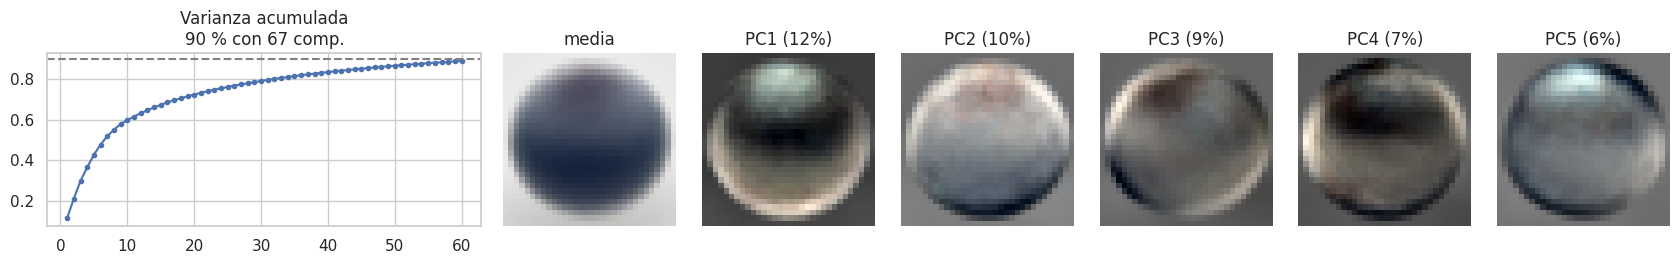

3 072 píxeles → 67 componentes (90 %) · 107 (95 %)


In [24]:
Xpix = pd.DataFrame(T32.reshape(len(T32), -1).astype(np.float32) / 255.0, columns=[f"p{i}" for i in range(T32[0].size)])
Pix_tr, Pix_va, Pix_te = Xpix[tr].reset_index(drop=True), Xpix[va].reset_index(drop=True), Xpix[te].reset_index(drop=True)
pca_pix = PCA(random_state=SEED).fit(Pix_tr)
cp = np.cumsum(pca_pix.explained_variance_ratio_); kp90 = int(np.searchsorted(cp, .90) + 1); kp95 = int(np.searchsorted(cp, .95) + 1)
fig, axs = plt.subplots(1, 7, figsize=(17, 2.8), gridspec_kw={"width_ratios": [2.4] + [1] * 6})
axs[0].plot(range(1, 61), cp[:60], "o-", ms=3); axs[0].axhline(.9, ls="--", c="gray"); axs[0].set_title(f"Varianza acumulada\n90 % con {kp90} comp.")
mu = pca_pix.mean_.reshape(32, 32, 3)
axs[1].imshow(mu[..., ::-1]); axs[1].set_title("media"); axs[1].axis("off")
for i in range(5):
    e_ = pca_pix.components_[i].reshape(32, 32, 3); e_ = (e_ - e_.min()) / (e_.max() - e_.min())
    axs[i + 2].imshow(e_[..., ::-1]); axs[i + 2].set_title(f"PC{i + 1} ({pca_pix.explained_variance_ratio_[i]:.0%})"); axs[i + 2].axis("off")
plt.tight_layout(); plt.show()
print(f"3 072 píxeles → {kp90} componentes (90 %) · {kp95} (95 %)")

### 7.7 Comparación final de estrategias
Se comparan las alternativas con el mismo protocolo (CV agrupada en entrenamiento y una comprobación en validación) según número de variables, rendimiento y tiempo de entrenamiento. La validación tiene unos 50 recortes, así que se usa solo como verificación y no como criterio de elección.

,estrategia,modelo,n_variables,AUC_CV,desv,AUC_val,recall_malo_val,ajuste_clf_ms
0,1. Base (sin ingeniería),Reg. logística,31,0.824,0.070,0.625,0.562,14.201
1,1. Base (sin ingeniería),Random forest,31,0.839,0.056,0.614,0.438,700.586
2,2. Base + nuevas (todas),Reg. logística,70,0.819,0.069,0.612,0.500,21.751
3,2. Base + nuevas (todas),Random forest,70,0.845,0.053,0.625,0.375,744.732
4,"3. Filtro (var → |ρ| → ANOVA), k=15",Reg. logística,15,0.811,0.063,0.554,0.500,35.113
5,"3. Filtro (var → |ρ| → ANOVA), k=15",Random forest,15,0.808,0.056,0.666,0.250,902.636
6,4. PCA 90 % (todas),Reg. logística,11,0.838,0.058,0.558,0.500,7.252
7,4. PCA 90 % (todas),Random forest,11,0.841,0.053,0.614,0.438,748.571
8,5. Filtro → PCA 90 %,Reg. logística,5,0.776,0.074,0.539,0.500,4.607
9,5. Filtro → PCA 90 %,Random forest,5,0.757,0.068,0.593,0.312,680.764


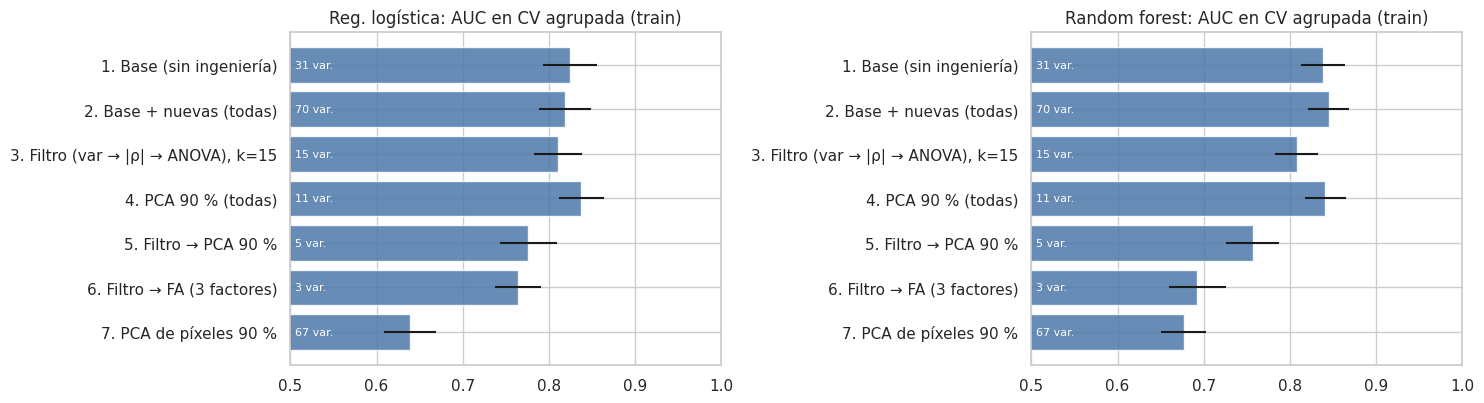

In [25]:
def estrategia(nombre, cols, pasos, X_tr, X_va):
    filas = []
    for mn, mod in [("Reg. logística", LR), ("Random forest", RF)]:
        pipe = Pipeline(pasos + [("clf", mod)])
        m, s = cv_auc(pipe, X_tr, yT, gT, reps=3)
        fit = clone(pipe).fit(X_tr, yT); p = puntuar(fit, X_va)
        Xt = Pipeline(pasos).fit(X_tr, yT).transform(X_tr)                   # tiempo del clasificador solo, sobre la matriz ya preparada
        t0 = time.perf_counter(); clone(mod).fit(Xt, yT); dt = (time.perf_counter() - t0) * 1000
        filas.append({"estrategia": nombre, "modelo": mn, "n_variables": None, "AUC_CV": m, "desv": s, "AUC_val": roc_auc_score(VAL.y, p),
                      "recall_malo_val": recall_score(VAL.y, (p >= .5).astype(int)), "ajuste_clf_ms": dt})
    return filas

fs_nom = lambda k: FiltroSeleccion(k, RHO)
casos = [
    ("1. Base (sin ingeniería)", BASE, [("prep", make_prep(BASE))], TRAIN[BASE], VAL[BASE], len(BASE)),
    ("2. Base + nuevas (todas)", FE_COLS, [("prep", make_prep(FE_COLS))], TRAIN[FE_COLS], VAL[FE_COLS], len(FE_COLS)),
    (f"3. Filtro (var → |ρ| → ANOVA), k={K_SEL}", CAND, [("prep", make_prep(CAND)), ("fs", fs_nom(K_SEL))], TRAIN[CAND], VAL[CAND], K_SEL),
    (f"4. PCA 90 % (todas)", CAND, [("prep", make_prep(CAND)), ("pca", PCA(.90, random_state=SEED))], TRAIN[CAND], VAL[CAND], k90),
    (f"5. Filtro → PCA 90 %", CAND, [("prep", make_prep(CAND)), ("fs", fs_nom(K_SEL)), ("pca", PCA(.90, random_state=SEED))], TRAIN[CAND], VAL[CAND], None),
    (f"6. Filtro → FA ({K_FA} factores)", CAND, [("prep", make_prep(CAND)), ("fs", fs_nom(K_SEL)), ("fa", FactorAnalysis(K_FA, rotation="varimax", random_state=SEED))], TRAIN[CAND], VAL[CAND], K_FA),
    (f"7. PCA de píxeles 90 %", None, [("pca", PCA(.90, random_state=SEED))], Pix_tr, Pix_va, kp90),
]
filas = []
for nom, cols, pasos, Xa, Xb, nv in casos:
    r = estrategia(nom, cols, pasos, Xa, Xb)
    if nv is None:   # número de variables tras el filtro y el PCA, ajustado en train
        pj = Pipeline(pasos).fit(Xa, yT); nv = pj.transform(Xa).shape[1]
    for x in r: x["n_variables"] = nv
    filas += r
cmpf = pd.DataFrame(filas)
display(cmpf.round(3))
cmp_lr = cmpf[cmpf.modelo == "Reg. logística"].set_index("estrategia")
fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))
for a_, mn in zip(ax, ["Reg. logística", "Random forest"]):
    d = cmpf[cmpf.modelo == mn]
    a_.barh(d.estrategia, d.AUC_CV, xerr=d.desv / np.sqrt(5), color="#4c78a8", alpha=.85)
    for i, (v, n_) in enumerate(zip(d.AUC_CV, d.n_variables)): a_.text(.505, i, f"{n_} var.", va="center", color="white", fontsize=8)
    a_.set_xlim(.5, 1); a_.invert_yaxis(); a_.set_title(f"{mn}: AUC en CV agrupada (train)")
plt.tight_layout(); plt.show()

La comparación muestra qué se gana y qué se pierde al reducir dimensiones. El filtro pasa de 70 a 15 variables con una pérdida de AUC que cae dentro del error entre pliegues, y conserva variables con significado físico, lo que facilita la interpretación. El PCA sobre todas las candidatas comprime a 11 componentes con un rendimiento equivalente o ligeramente superior, pero sus componentes mezclan variables y son más difíciles de explicar. Encadenar filtro y luego PCA o FA (5 y 3 variables) sí degrada el AUC, porque se comprime dos veces la misma información. El PCA de píxeles es la representación menos informativa para los modelos clásicos. Por eso se adopta el filtro como tabla principal, por su interpretabilidad, y el PCA como alternativa compacta de mejor rendimiento.

## 8. Conjunto final y exportación
Los transformadores ajustados con entrenamiento se aplican a los tres conjuntos y se exportan solo tablas agregadas (sin imágenes). Se generan las variables seleccionadas (features_seleccionadas_*.csv, en escala Yeo–Johnson + estandarización) y sus componentes principales (features_pca_*.csv) para modelos que prefieran un espacio compacto. También se guardan el ranking (ranking_caracteristicas.csv), los transformadores ajustados (pipeline_fe.joblib) y los parámetros de normalización de píxeles (parametros_pixeles.json).

Para la CNN, los píxeles no pasan por Yeo–Johnson: se escalan a [0, 1] y se estandarizan por canal con la media y desviación de entrenamiento, lo que favorece la convergencia. Si se usa un modelo preentrenado (MobileNetV2, EfficientNet), se añadirá su preprocesamiento propio en la fase de modelado.

In [26]:
pca_fin = Pipeline([("prep", make_prep(CAND)), ("fs", fs_nom(K_SEL)), ("pca", PCA(.90, random_state=SEED))]).fit(TRAIN[CAND], yT)
PCN = [f"PC{i + 1}" for i in range(pca_fin.named_steps["pca"].n_components_)]

def exportar(d, nombre):
    meta = d[["crop_id", "grupo", "clase", "particion"] + (["defecto"] if HAY_DEFECTO else [])].reset_index(drop=True)
    Xs = fs_final.transform(d[CAND]).reset_index(drop=True)
    X_def = codificar_defecto(d).reset_index(drop=True)
    pd.concat([meta, d[["y"]].reset_index(drop=True), Xs, X_def], axis=1).to_csv(OUT_DIR / f"features_seleccionadas_{nombre}.csv", index=False)
    pd.concat([meta, d[["y"]].reset_index(drop=True), pd.DataFrame(pca_fin.transform(d[CAND]), columns=PCN)], axis=1).to_csv(OUT_DIR / f"features_pca_{nombre}.csv", index=False)
    return Xs

Xs_tr, Xs_va, Xs_te = exportar(TRAIN, "train"), exportar(VAL, "val"), exportar(TEST, "test")
print("Dimensiones (muestras × variables seleccionadas):", Xs_tr.shape, Xs_va.shape, Xs_te.shape)
print("Media/desv. en train:", round(float(Xs_tr.mean().abs().max()), 3), "/", Xs_tr.std().round(2).unique())
print("Val (transformado con parámetros de train; no queda exactamente en media 0 / desv. 1, y es lo correcto):",
      "|media| máx. =", round(float(Xs_va.mean().abs().max()), 2), "· desv. entre", round(float(Xs_va.std().min()), 2), "y", round(float(Xs_va.std().max()), 2))

rk.assign(retenida=lambda d: d.index.isin(SEL), descartada_por_redundancia=lambda d: d.index.isin(drop_c)).to_csv(OUT_DIR / "ranking_caracteristicas.csv")
joblib.dump({"features_seleccionadas": SEL, "pipeline_seleccion": fs_final, "pipeline_pca": pca_fin, "bins": {"tamano": kb_tam, "rojizo": kb_roj},
             "onehot_defecto": ohe, "umbral_asimetria": SKEW_TH, "rho": RHO, "k": K_SEL}, OUT_DIR / "pipeline_fe.joblib")

rgb = C200[tr][..., ::-1].astype(np.float32) / 255.0
pix = {"orden_canales": "RGB", "escala": "x/255", "media_train": rgb.mean(axis=(0, 1, 2)).round(5).tolist(), "desv_train": rgb.std(axis=(0, 1, 2)).round(5).tolist(),
       "tamano_entrada": [CROP_SIZE, CROP_SIZE, 3], "n_train": int(tr.sum())}
json.dump(pix, open(OUT_DIR / "parametros_pixeles.json", "w"), indent=2)
print("Normalización de píxeles para la CNN (train):", pix["media_train"], pix["desv_train"])
print("Archivos en", OUT_DIR.resolve(), ":", sorted(p.name for p in OUT_DIR.glob("*")))

Dimensiones (muestras × variables seleccionadas): (258, 15) (45, 15) (50, 15)
Media/desv. en train: 0.0 / [1. 0.]
Val (transformado con parámetros de train; no queda exactamente en media 0 / desv. 1, y es lo correcto): |media| máx. = 0.17 · desv. entre 0.0 y 1.13
Normalización de píxeles para la CNN (train): [0.5120099782943726, 0.5329099893569946, 0.5783299803733826] [0.3243800103664398, 0.3064199984073639, 0.27498000860214233]
Archivos en /content/drive/.shortcut-targets-by-id/1D3LM7dIWfg66NB2euECFRQF0hvwhPH31/ProyectoIntegrador/Datos/resultados_avance2 : ['embeddings_resnet18.npz', 'features_pca_test.csv', 'features_pca_train.csv', 'features_pca_val.csv', 'features_seleccionadas_test.csv', 'features_seleccionadas_train.csv', 'features_seleccionadas_val.csv', 'parametros_pixeles.json', 'pipeline_fe.joblib', 'ranking_caracteristicas.csv']


### 8.1 Resumen de decisiones
| Etapa | Técnica | Parámetros | Justificación |
|---|---|---|---|
| Calidad | Exclusión por radio atípico y fruto no segmentable | Q1 − 1.5·IQR; área < 30 % | Fallas de adquisición, no variación del producto |
| Partición | `StratifiedGroupKFold` agrupado por bloques de 5 imágenes consecutivas | 70/15/15 | Evita fuga por iluminación compartida (hay autocorrelación entre vecinos); conserva proporción de clases |
| Construcción | 15 derivadas + 22 descriptores locales (colas, gradiente, LBP) | ver 3.1–3.2 | Conocimiento de dominio: color, textura, forma, normalización por fondo |
| Discretización | Cuantiles (radio) y la estrategia más balanceada para `pct_rojizo` | 3 bins | Calibre comercial; evita bins vacíos |
| Codificación | Etiqueta (objetivo), ordinal (bins) y one-hot de `defecto` si existe | `min_frequency=10` | Nominal vs. ordinal; `defecto` no es predictor (fuga); la v2 no lo trae |
| Transformación | Yeo–Johnson | \|asimetría\| > 1 | Admite ceros/negativos; reduce colas |
| Escalamiento | Estandarización (tras Yeo–Johnson) | media 0, desv. 1 | Equidad entre variables y convergencia |
| Filtros | Varianza → \|ρ\| Spearman → ANOVA F (consenso con χ², IM) | 0.005 (+ casi constantes > 95 %); 0.9; k por tolerancia de 0.01 AUC | Reduce redundancia/ruido sin usar el modelo |
| Extracción | PCA, FA (varimax), PCA de píxeles | 90 % de varianza; Kaiser | Compresión e interpretación |

## 9. Conclusiones: fase *Preparación de los datos* (CRISP-ML(Q))
La preparación de los datos abarca seleccionar, limpiar, construir, integrar y dar formato, y su aseguramiento de calidad exige documentar, evitar la fuga y garantizar la reproducibilidad. La síntesis siguiente se genera con los resultados de esta ejecución.

In [27]:
mejor_est = cmp_lr["AUC_CV"].idxmax()
f_lr = cmpf[cmpf.modelo == "Reg. logística"].set_index("estrategia"); f_rf = cmpf[cmpf.modelo == "Random forest"].set_index("estrategia")
e1, e2, e3, e4, e6, e7 = [f_lr.index[i] for i in (0, 1, 2, 3, 5, 6)]
parrafos = []
parrafos.append(f"**Seleccionar y limpiar.** De {len(et)} recortes etiquetados se conservaron **{len(datos)}** ({int(qc.any(axis=1).sum())} excluidos por radio atípico o fruto no segmentable) y se particionaron por bloques de captura "
         f"(train {int(tr.sum())}, val {int(va.sum())}, test {int(te.sum())}) con {datos.y.mean():.0%} de frutos malos; no se imputó ninguna etiqueta.")
def cambio(a, b, tol=0.01):
    d = b - a
    return "se mantiene" if abs(d) < tol else ("mejora" if d > 0 else "empeora")

sd_cv = float(cmpf.desv.mean())
a1, a2, a3 = f_lr.loc[e1, "AUC_CV"], f_lr.loc[e2, "AUC_CV"], f_lr.loc[e3, "AUC_CV"]
r1, r2, r3 = f_rf.loc[e1, "AUC_CV"], f_rf.loc[e2, "AUC_CV"], f_rf.loc[e3, "AUC_CV"]
gana_fe = (a2 - a1 >= .01) or (r2 - r1 >= .01)
n_nuevas = sum(c in NEW + ORD + LOCAL for c in SEL)
top_nuevas = ", ".join(rel_new.sort_values(ascending=False).head(3).index)
lo, hi = f_lr.AUC_CV.min(), f_lr.AUC_CV.max()

parrafos.append(f"**Construir.** A las {len(BASE)} características base se añadieron {len(NEW)} derivadas con conocimiento del dominio (índices de color, codificación cíclica del matiz, razones de canales, normalización por el fondo, "
         f"rugosidad de forma/textura, extensión de lesión), {len(LOCAL)} descriptores locales (colas de la distribución de color, gradiente, LBP) y 2 discretizadas. "
         f"AUC en CV con regresión logística: {a1:.3f} (solo base) → {a2:.3f} (todas), {cambio(a1, a2)}; con *random forest*: {r1:.3f} → {r2:.3f}, {cambio(r1, r2)}. "
         + ("Las nuevas características aportan rendimiento. " if gana_fe else
            f"En esta base **la ingeniería de características no aumenta el AUC** de los modelos de referencia: las diferencias son del orden del error entre pliegues (≈ {sd_cv:.2f}) y, con {int(tr.sum())} recortes de entrenamiento, "
            "añadir variables favorece el sobreajuste. Su aporte está en la interpretabilidad (variables con significado físico) y en identificar qué mide mejor el defecto. ")
         + f"Las nuevas con mayor poder univariado son {top_nuevas}.")
parrafos.append(f"**Transformar y escalar.** {len(sesg)} características estaban sesgadas (|asimetría| > 1); Yeo–Johnson redujo la asimetría media de {comp.antes.abs().mean():.2f} a {comp['después'].abs().mean():.2f}. "
         f"La estandarización llevó todas las variables a media 0 / desviación 1 y la regresión logística pasó de {it_sin} a {it_yj} iteraciones (convergencia {'lograda' if conv.loc['Yeo–Johnson + estand.', 'convergió en ≤100 iter.'] else 'aún incompleta'} con el límite por defecto), "
         f"con un AUC medio de modelos sensibles a la escala de {sin:.3f} → {yj:.3f}.")
parrafos.append(f"**Seleccionar y extraer.** Varianza ({len(baja_var)} eliminada(s)) → correlación ({len(drop_c)} redundantes con |ρ| ≥ {RHO}) → ANOVA top-k (consenso con χ², información mutua y AUC de Mann–Whitney): "
         f"de {len(FE_COLS)} candidatas se retienen **{len(SEL)}** ({n_nuevas} de ellas construidas en este avance). "
         f"Con {len(SEL)} variables la regresión logística {cambio(a2, a3)} ({a2:.3f} con las {len(FE_COLS)} → {a3:.3f}) y el *random forest* {cambio(r2, r3)} ({r2:.3f} → {r3:.3f}); "
         f"el tiempo de ajuste de la regresión logística baja de {f_lr.loc[e2, 'ajuste_clf_ms']:.0f} a {f_lr.loc[e3, 'ajuste_clf_ms']:.0f} ms. "
         + ("La reducción es prácticamente gratuita en rendimiento. " if (a3 - a2 > -.01 and r3 - r2 > -.01) else
            "La compactación tiene un costo en el *random forest* (que ya descarta variables por sí mismo), por lo que se justifica por menor complejidad e interpretabilidad más que por rendimiento. ")
         + f"El PCA necesita {k90} componentes para el 90 % de la varianza ({len(CAND)} → {k90}); el análisis factorial (Bartlett p {'< 0.001' if p_b < .001 else f'= {p_b:.3f}'}, KMO = {kmo_g:.2f}) resume {len(SEL)} variables en {K_FA} factores interpretables; "
         f"el PCA de píxeles comprime 3 072 valores en {kp90} componentes, pero rinde peor (AUC_CV {f_lr.loc[e7, 'AUC_CV']:.2f} con regresión logística), por lo que no se adopta.")
parrafos.append(f"**Mejor estrategia (regresión logística, CV):** *{mejor_est}* (AUC_CV = {f_lr.loc[mejor_est, 'AUC_CV']:.3f}). El rango entre las estrategias evaluadas es {lo:.2f}–{hi:.2f} frente a un error entre pliegues ≈ {sd_cv:.2f}: "
         f"las diferencias no son concluyentes. En validación ({int(va.sum())} recortes) la estrategia 3 obtiene AUC = {f_lr.loc[e3, 'AUC_val']:.3f} y recall de *malo* = {f_lr.loc[e3, 'recall_malo_val']:.2f}, "
         "lejos de la meta de recall ≥ 0.90 del Avance 0: esta preparación es la base para el modelado, no el clasificador final.")
parrafos.append(f"**Objetivos del avance.** *2.3 (nuevas características):* se construyeron {len(NEW) + len(LOCAL) + len(ORD)} características nuevas; "
         + ("elevan el rendimiento de los modelos de referencia." if gana_fe else
            f"no elevan el AUC de los modelos de referencia en esta base, pero {n_nuevas} de las {len(SEL)} variables finales son nuevas, es decir, aportan la señal que la selección conserva.")
         + f" *2.4 (sesgo y convergencia):* la asimetría media bajó de {comp.antes.abs().mean():.2f} a {comp['después'].abs().mean():.2f} con Yeo–Johnson y la regresión logística pasó de {it_sin} a {it_yj} iteraciones.")
display(Markdown("\n\n".join("- " + l for l in parrafos)))

- **Seleccionar y limpiar.** De 353 recortes etiquetados se conservaron **353** (0 excluidos por radio atípico o fruto no segmentable) y se particionaron por bloques de captura (train 258, val 45, test 50) con 37% de frutos malos; no se imputó ninguna etiqueta.

- **Construir.** A las 31 características base se añadieron 15 derivadas con conocimiento del dominio (índices de color, codificación cíclica del matiz, razones de canales, normalización por el fondo, rugosidad de forma/textura, extensión de lesión), 22 descriptores locales (colas de la distribución de color, gradiente, LBP) y 2 discretizadas. AUC en CV con regresión logística: 0.824 (solo base) → 0.819 (todas), se mantiene; con *random forest*: 0.839 → 0.845, se mantiene. En esta base **la ingeniería de características no aumenta el AUC** de los modelos de referencia: las diferencias son del orden del error entre pliegues (≈ 0.06) y, con 258 recortes de entrenamiento, añadir variables favorece el sobreajuste. Su aporte está en la interpretabilidad (variables con significado físico) y en identificar qué mide mejor el defecto. Las nuevas con mayor poder univariado son rojez_std, rojez_p99, rojizo_saturado.

- **Transformar y escalar.** 25 características estaban sesgadas (|asimetría| > 1); Yeo–Johnson redujo la asimetría media de 2.15 a 0.25. La estandarización llevó todas las variables a media 0 / desviación 1 y la regresión logística pasó de 100 a 59 iteraciones (convergencia lograda con el límite por defecto), con un AUC medio de modelos sensibles a la escala de 0.716 → 0.834.

- **Seleccionar y extraer.** Varianza (1 eliminada(s)) → correlación (27 redundantes con |ρ| ≥ 0.9) → ANOVA top-k (consenso con χ², información mutua y AUC de Mann–Whitney): de 70 candidatas se retienen **15** (9 de ellas construidas en este avance). Con 15 variables la regresión logística se mantiene (0.819 con las 70 → 0.811) y el *random forest* empeora (0.845 → 0.808); el tiempo de ajuste de la regresión logística baja de 22 a 35 ms. La compactación tiene un costo en el *random forest* (que ya descarta variables por sí mismo), por lo que se justifica por menor complejidad e interpretabilidad más que por rendimiento. El PCA necesita 11 componentes para el 90 % de la varianza (69 → 11); el análisis factorial (Bartlett p < 0.001, KMO = 0.81) resume 15 variables en 3 factores interpretables; el PCA de píxeles comprime 3 072 valores en 67 componentes, pero rinde peor (AUC_CV 0.64 con regresión logística), por lo que no se adopta.

- **Mejor estrategia (regresión logística, CV):** *4. PCA 90 % (todas)* (AUC_CV = 0.838). El rango entre las estrategias evaluadas es 0.64–0.84 frente a un error entre pliegues ≈ 0.06: las diferencias no son concluyentes. En validación (45 recortes) la estrategia 3 obtiene AUC = 0.554 y recall de *malo* = 0.50, lejos de la meta de recall ≥ 0.90 del Avance 0: esta preparación es la base para el modelado, no el clasificador final.

- **Objetivos del avance.** *2.3 (nuevas características):* se construyeron 39 características nuevas; no elevan el AUC de los modelos de referencia en esta base, pero 9 de las 15 variables finales son nuevas, es decir, aportan la señal que la selección conserva. *2.4 (sesgo y convergencia):* la asimetría media bajó de 2.15 a 0.25 con Yeo–Johnson y la regresión logística pasó de 100 a 59 iteraciones.

### Conclusión general en el contexto de CRISP-ML(Q)
Los hallazgos del EDA (asimetría, redundancia, confusión con la sesión de captura, desbalance moderado) se tradujeron en acciones verificables: Yeo–Johnson, filtros de varianza y correlación, normalización por el fondo, partición por bloques de captura y pesos de clase.

En calidad, no hay fuga porque todo se ajusta con entrenamiento, los filtros supervisados se evalúan dentro de cada pliegue, los identificadores quedan fuera de los predictores y el conjunto de prueba sigue intacto. El trabajo es reproducible (seed fija, pipeline serializado, parámetros de píxeles guardados) y cada decisión tiene su prueba en este cuaderno.

De cara al modelado, quedan tres riesgos. Las características artesanales discriminan de forma moderada y algunos defectos (cicatriz, golpe leve) dependen de la textura local, por lo que la CNN con transfer learning y aumento de datos sigue siendo la vía principal, y las características servirán como línea base interpretable y para analizar errores. El conjunto es pequeño, así que las métricas tienen intervalos amplios y se usarán validación cruzada agrupada y curvas de aprendizaje. Y la deriva de iluminación entre sesiones puede degradar el modelo en producción, por lo que conviene monitorear fondo_brillo, brillo_rel y la distribución de las variables seleccionadas (Monitoring and Maintenance).

La preparación queda cerrada. Se entregan las tablas listas para modelos clásicos, la normalización de la CNN, la partición reproducible y el pipeline ajustado, y el siguiente avance incorpora los modelos sobre estos datos.